# Real-Time Abnormal Object Detection for Video Surveillance in Smart Cities

In [ ]:
!pip install ultralytics opencv-python torch torchvision
!pip install numpy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.3 MB/s eta 0:00:00


In [ ]:
path="/content/drive/MyDrive/Btech_Project_major/DATASETS/Guns and knifes detection in CCTV videos.zip"
unzipped_path="/content/dataset"
!unzip "{path}" -d "{unzipped_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2274).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2275).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2276).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2277).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2278).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2279).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (228).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2280).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2281).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2282).txt  
  inflating: /content/dataset/combined_gunsnknifes/train/labels/armas (2283).txt  
  inflating: /content/dataset/combine

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/dataset/combined_gunsnknifes/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    name='weapon_detection'
)

# Evaluate model
metrics = model.val()
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.195 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/combined_gunsnknifes/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ke

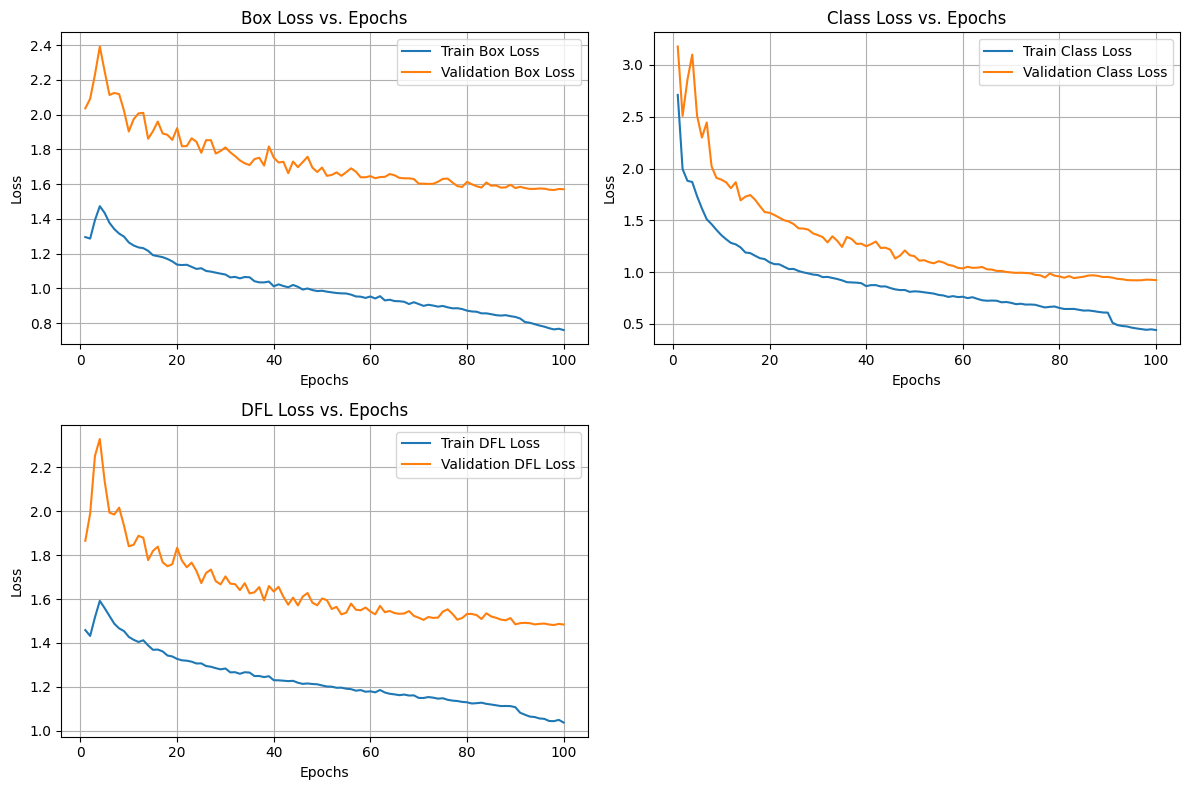

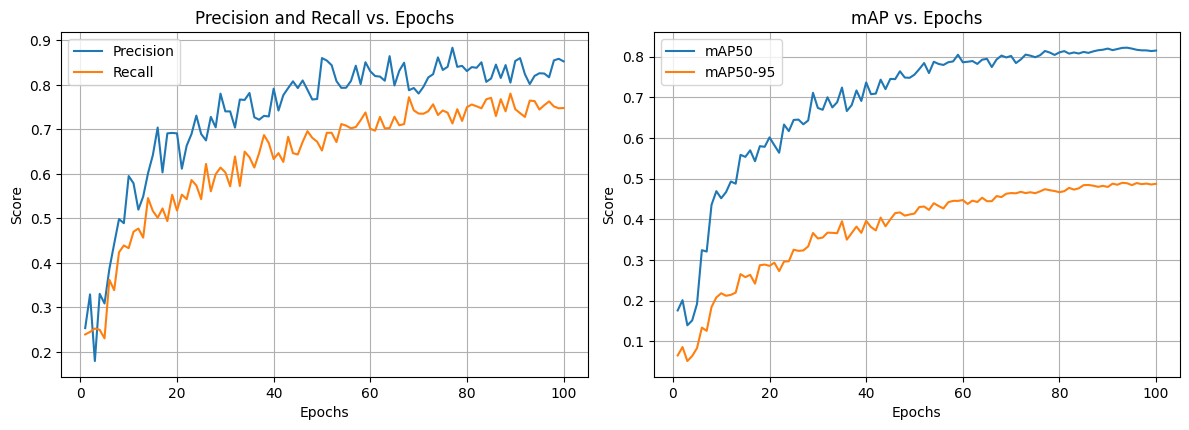

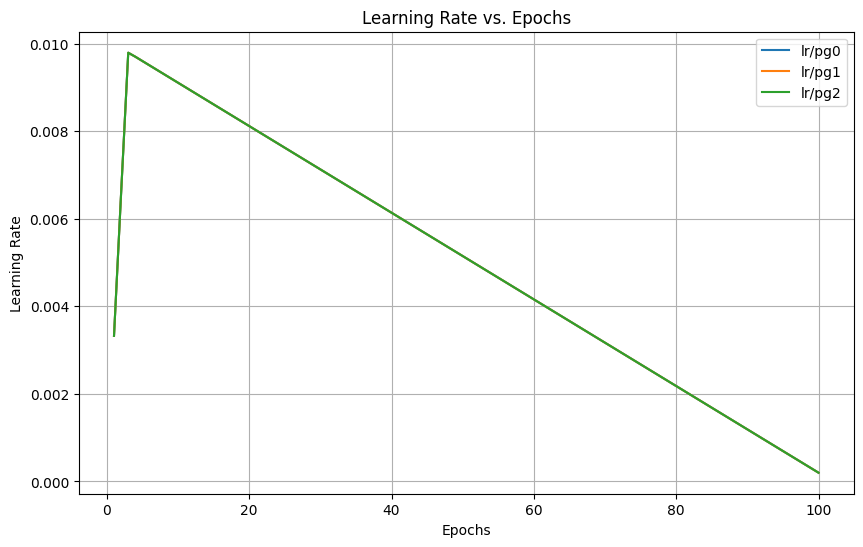

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/01_ Btech Project/built-model_v1/knives&gun&pistol_detection part_cctv/results.csv')

# Plotting the losses
plt.figure(figsize=(12, 8))

# Box Loss
plt.subplot(2, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Validation Box Loss')
plt.title('Box Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Class Loss
plt.subplot(2, 2, 2)
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
plt.plot(df['epoch'], df['val/cls_loss'], label='Validation Class Loss')
plt.title('Class Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# DFL Loss
plt.subplot(2, 2, 3)
plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')
plt.plot(df['epoch'], df['val/dfl_loss'], label='Validation DFL Loss')
plt.title('DFL Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('losses.png')

# Plotting the metrics
plt.figure(figsize=(12, 8))

# Precision and Recall
plt.subplot(2, 2, 1)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.title('Precision and Recall vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# mAP50 and mAP50-95
plt.subplot(2, 2, 2)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.title('mAP vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('metrics.png')

# Plotting the learning rate
plt.figure(figsize=(10, 6))
plt.plot(df['epoch'], df['lr/pg0'], label='lr/pg0')
plt.plot(df['epoch'], df['lr/pg1'], label='lr/pg1')
plt.plot(df['epoch'], df['lr/pg2'], label='lr/pg2')
plt.title('Learning Rate vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)
plt.savefig('learning_rate.png')

In [ ]:
# ==============================
# STEP 1: Setup
# ==============================
from ultralytics import YOLO
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set paths
PROJECT_NAME = "weapon_detection"
SAVE_DIR = f"/content/drive/MyDrive/yolo_runs/{PROJECT_NAME}"
DATA_YAML = "/content/dataset/combined_gunsnknifes/data.yaml"

# Make sure save dir exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ==============================
# STEP 2: Check if checkpoint exists
# ==============================
last_ckpt = os.path.join(SAVE_DIR, "weights", "last.pt")

if os.path.exists(last_ckpt):
    print("🔄 Resuming training from last checkpoint...")
    model = YOLO(last_ckpt)
    resume_flag = True
else:
    print("🚀 Starting fresh training with yolov8n.pt...")
    model = YOLO("yolov8n.pt")   # You can change to yolov8s.pt etc.
    resume_flag = False

# ==============================
# STEP 3: Train (or Resume)
# ==============================
results = model.train(
    data=DATA_YAML,
    epochs=100,            # total number of epochs
    imgsz=640,             # image size
    batch=16,              # adjust based on GPU memory
    device=0,              # use GPU
    name=PROJECT_NAME,
    project=SAVE_DIR,      # save directly in Google Drive
    resume=resume_flag,    # resume if checkpoint exists
    cache=True,            # cache dataset for speed
    workers=4,             # dataloader workers
    amp=True               # mixed precision (faster on T4/V100/A100)
)

# ==============================
# STEP 4: Evaluate model
# ==============================
metrics = model.val()
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")


# CASIA -B

In [ ]:
# SCRIPT 1: TRAINING THE GAIT ANOMALY MODEL

import torch
import torch.nn as nn
from torchvision.models.detection import keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
import numpy as np
import cv2
import os
import glob
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
PATH="/content/drive/MyDrive/Btech_Project_major/DATASETS/gait_dataset/CASIA.zip"
unzipped_path = "/content/CASIA_B"
!unzip "{PATH}" -d "{unzipped_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-053.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-054.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-055.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-056.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-057.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-058.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-059.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-060.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-061.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-062.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-063.png  
  inflating: /content/CASIA_B/output/124/cl-02/144/124-cl-02-144-064.png  
  inflating: /content/CASIA_B/output/124/cl-02/14

In [ ]:
print("--- Preparing for Gait Model Training ---")

# ==============================================================================
# STEP 1: DEFINE THE PREPROCESSING FUNCTION
# ==============================================================================

def preprocess_video_dataset(video_dir, pose_estimator, device):
    """
    Processes all 'nm' (normal walk) videos in the CASIA-B directory,
    extracts pose keypoints, and returns a list of fixed-length sequences.
    """
    all_sequences = []
    # Find all "normal walk" videos (nm-01 to nm-06)
    video_files = glob.glob(os.path.join(video_dir, '**/nm*.avi'), recursive=True)

    if not video_files:
        print(f"FATAL: No 'nm-*.avi' videos found in '{video_dir}'. Please check the path.")
        return np.array([])

    print(f"Found {len(video_files)} normal walking videos to process...")

    for i, video_path in enumerate(sorted(video_files)):
        cap = cv2.VideoCapture(video_path)
        keypoint_sequence = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            img_tensor = F.to_tensor(frame).unsqueeze(0).to(device)
            with torch.no_grad():
                output = pose_estimator(img_tensor)

            if len(output[0]['keypoints']) > 0:
                # Get the keypoints for the most confident person, flatten (17 joints * 2 coords = 34 features)
                keypoints = output[0]['keypoints'][0, :, :2].cpu().numpy().flatten()
                keypoint_sequence.append(keypoints)

        cap.release()

        # Create fixed-length, overlapping sequences from the video's keypoints
        SEQUENCE_LENGTH = 15
        STEP = 5
        if len(keypoint_sequence) >= SEQUENCE_LENGTH:
            for j in range(0, len(keypoint_sequence) - SEQUENCE_LENGTH, STEP):
                all_sequences.append(keypoint_sequence[j:j + SEQUENCE_LENGTH])

        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(video_files)} videos...")

    return np.array(all_sequences, dtype=np.float32)


--- Preparing for Gait Model Training ---


In [ ]:
# ==============================================================================
# STEP 2: DEFINE THE GAIT AUTOENCODER MODEL
# ==============================================================================

class GaitAutoencoder(nn.Module):
    def __init__(self, input_features, hidden_dim, n_layers=2):
        super(GaitAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_features, hidden_dim, n_layers, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(hidden_dim, input_features, n_layers, batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (hidden, cell) = self.encoder(x)
        last_layer_hidden = hidden[-1]
        decoder_input = last_layer_hidden.unsqueeze(1).repeat(1, x.size(1), 1)
        reconstruction, _ = self.decoder(decoder_input)
        return reconstruction


In [ ]:
# This command lists all subdirectories. Look for the one containing folders like '001', '002', etc.
!ls -R /content/CASIA_B/

Streaming output truncated to the last 5000 lines.
123-cl-02-090-053.png  123-cl-02-090-071.png  123-cl-02-090-089.png
123-cl-02-090-054.png  123-cl-02-090-072.png  123-cl-02-090-090.png
123-cl-02-090-055.png  123-cl-02-090-073.png  123-cl-02-090-091.png
123-cl-02-090-056.png  123-cl-02-090-074.png  123-cl-02-090-092.png
123-cl-02-090-057.png  123-cl-02-090-075.png  123-cl-02-090-093.png
123-cl-02-090-058.png  123-cl-02-090-076.png  123-cl-02-090-094.png
123-cl-02-090-059.png  123-cl-02-090-077.png  123-cl-02-090-095.png
123-cl-02-090-060.png  123-cl-02-090-078.png  123-cl-02-090-096.png
123-cl-02-090-061.png  123-cl-02-090-079.png  123-cl-02-090-097.png

/content/CASIA_B/output/123/cl-02/108:
123-cl-02-108-044.png  123-cl-02-108-064.png  123-cl-02-108-084.png
123-cl-02-108-045.png  123-cl-02-108-065.png  123-cl-02-108-085.png
123-cl-02-108-046.png  123-cl-02-108-066.png  123-cl-02-108-086.png
123-cl-02-108-047.png  123-cl-02-108-067.png  123-cl-02-108-087.png
123-cl-02-108-048.png  12

In [ ]:
# SCRIPT 1: FINAL TRAINING SCRIPT FOR IMAGE FRAME DATASET

import torch
import torch.nn as nn
from torchvision.models.detection import keypointrcnn_resnet50_fpn, KeypointRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
import numpy as np
import cv2
import os
import glob
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm # Adding a progress bar for better feedback

print("--- Preparing for Gait Model Training from Image Frames ---")

# ==============================================================================
# STEP 1: UPDATED PREPROCESSING FUNCTION FOR IMAGE DIRECTORIES
# ==============================================================================

def preprocess_image_frame_dataset(base_dir, pose_estimator, device):
    """
    Processes directories of image frames for 'nm' (normal walk) sequences,
    extracts pose keypoints from each image, and returns a list of sequences.
    """
    all_sequences = []
    # Find all individual sequence directories for normal walking (e.g., .../001/nm-01/000)
    sequence_dirs = glob.glob(os.path.join(base_dir, '*/nm*/*'))

    if not sequence_dirs:
        print(f"FATAL: No normal walk sequence directories ('*/nm*/*') found in '{base_dir}'.")
        return np.array([])

    print(f"Found {len(sequence_dirs)} normal walking sequence directories to process...")

    # Use tqdm for a progress bar
    for seq_dir in tqdm(sorted(sequence_dirs), desc="Processing Sequences"):
        keypoint_sequence = []

        # Get a sorted list of all images in the directory
        image_files = sorted(glob.glob(os.path.join(seq_dir, '*.png')))

        for img_path in image_files:
            try:
                frame = cv2.imread(img_path)
                if frame is None: continue

                img_tensor = F.to_tensor(frame).unsqueeze(0).to(device)
                with torch.no_grad():
                    output = pose_estimator(img_tensor)

                if len(output) > 0 and 'keypoints' in output[0] and len(output[0]['keypoints']) > 0:
                    keypoints = output[0]['keypoints'][0, :, :2].cpu().numpy().flatten()
                    keypoint_sequence.append(keypoints)
            except Exception as e:
                print(f"Skipping image {img_path} due to error: {e}")

        # Create fixed-length, overlapping sequences from the collected keypoints
        SEQUENCE_LENGTH = 15
        STEP = 5
        if len(keypoint_sequence) >= SEQUENCE_LENGTH:
            for i in range(0, len(keypoint_sequence) - SEQUENCE_LENGTH, STEP):
                all_sequences.append(keypoint_sequence[i:i + SEQUENCE_LENGTH])

    return np.array(all_sequences, dtype=np.float32)

# ==============================================================================
# STEP 2: DEFINE THE GAIT AUTOENCODER MODEL (No changes)
# ==============================================================================

class GaitAutoencoder(nn.Module):
    def __init__(self, input_features, hidden_dim, n_layers=2):
        super(GaitAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_features, hidden_dim, n_layers, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(hidden_dim, input_features, n_layers, batch_first=True, dropout=0.2)

    def forward(self, x):
        _, (hidden, cell) = self.encoder(x)
        last_layer_hidden = hidden[-1]
        decoder_input = last_layer_hidden.unsqueeze(1).repeat(1, x.size(1), 1)
        reconstruction, _ = self.decoder(decoder_input)
        return reconstruction

# ==============================================================================
# STEP 3: RUN PREPROCESSING AND TRAIN THE MODEL
# ==============================================================================

if __name__ == '__main__':
    # --- PATHS CONFIGURED FOR YOUR FOLDER STRUCTURE ---
    # This is the base directory that contains the subject folders '001', '002', etc.
    CASIA_B_DIR = '/content/CASIA_B/output'

    OUTPUT_DATA_FILE = 'casia_b_walking_keypoints.npy'
    OUTPUT_MODEL_FILE = 'gait_autoencoder_video.pth'
    OUTPUT_SCALER_FILE = 'gait_scaling_params.npz'

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Preprocess Data (if needed) ---
    if not os.path.exists(OUTPUT_DATA_FILE):
        print("Loading pose estimator model for preprocessing...")
        pose_estimator_model = keypointrcnn_resnet50_fpn(weights=KeypointRCNN_ResNet50_FPN_Weights.DEFAULT).to(device)
        pose_estimator_model.eval()

        print("Starting image frame preprocessing...")
        gait_data = preprocess_image_frame_dataset(CASIA_B_DIR, pose_estimator_model, device)

        if gait_data.size > 0:
            np.save(OUTPUT_DATA_FILE, gait_data)
            print(f"\nSuccessfully preprocessed data and saved to {OUTPUT_DATA_FILE}")
            print(f"Shape of training data: {gait_data.shape}")
        else:
            raise RuntimeError("Preprocessing failed. No data was generated. Check your dataset path.")
    else:
        print(f"'{OUTPUT_DATA_FILE}' already exists. Skipping preprocessing.")

    # --- Train the Model ---
    try:
        gait_sequences = np.load(OUTPUT_DATA_FILE)

        mean, std = gait_sequences.mean(axis=(0, 1)), gait_sequences.std(axis=(0, 1))
        std[std == 0] = 1
        np.savez(OUTPUT_SCALER_FILE, mean=mean, std=std)
        print(f"Scaling parameters saved to {OUTPUT_SCALER_FILE}")

        normalized_sequences = (gait_sequences - mean) / std

        print("\nTraining the Gait Autoencoder...")
        INPUT_FEATURES = normalized_sequences.shape[2]
        HIDDEN_DIM = 64
        model = GaitAutoencoder(INPUT_FEATURES, HIDDEN_DIM, n_layers=2).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        dataset = TensorDataset(torch.from_numpy(normalized_sequences).float())
        loader = DataLoader(dataset, batch_size=128, shuffle=True)

        num_epochs = 75
        for epoch in range(num_epochs):
            epoch_loss = 0
            for data, in loader:
                data = data.to(device)
                reconstruction = model(data)
                loss = criterion(reconstruction, data)
                optimizer.zero_grad(); loss.backward(); optimizer.step()
                epoch_loss += loss.item()
            if (epoch + 1) % 5 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss / len(loader):.6f}')

        torch.save(model.state_dict(), OUTPUT_MODEL_FILE)
        print(f"\nSuccessfully trained and saved the gait model as '{OUTPUT_MODEL_FILE}'!")

    except FileNotFoundError:
        print(f"\nERROR: Training data '{OUTPUT_DATA_FILE}' not found. Please run the preprocessing step first.")

--- Preparing for Gait Model Training from Image Frames ---
Using device: cuda
Loading pose estimator model for preprocessing...
Starting image frame preprocessing...
Found 8154 normal walking sequence directories to process...


Processing Sequences:  14%|█▍        | 1177/8154 [2:37:09<10:34:47,  5.46s/it]

# Gait HuGaDB

In [ ]:
path='/content/drive/MyDrive/Btech_Project_major/DATASETS/gait_dataset/HuGaDB.zip'

In [ ]:
unzipped_path = "/content/hugadb_dataset"
!unzip "{path}" -d "{unzipped_path}"

Archive:  /content/drive/MyDrive/Btech_Project_major/DATASETS/gait_dataset/HuGaDB.zip
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_00.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_01.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_02.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_03.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_04.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_05.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_06.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_07.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_08.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_09.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_10.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_11.csv  
  inflating: /content/hugadb_dataset/HuGaDB_v2_various_01_12.csv  
  inflating: /content/hugadb_dataset/HuGaDB

In [ ]:
import os
import pandas as pd
import glob

dataset_path = "/content/hugadb_dataset/"
csv_files = glob.glob(os.path.join(dataset_path, '*.csv'))

if not csv_files:
    print(f"No CSV files found in {dataset_path}")
else:
    for file_path in csv_files:
        try:
            df = pd.read_csv(file_path)
            if 'activity' in df.columns:
                unique_activities = df['activity'].unique()
                print(f"Unique activities in {os.path.basename(file_path)}: {unique_activities}")
            else:
                print(f"No 'activity' column found in {os.path.basename(file_path)}")
        except Exception as e:
            print(f"Error processing {os.path.basename(file_path)}: {e}")

Unique activities in HuGaDB_v2_various_17_20.csv: ['standing' 'up_by_elevator' 'down_by_elevator']
Unique activities in HuGaDB_v2_various_07_04.csv: ['standing' 'walking' 'going_up']
Unique activities in HuGaDB_v2_various_05_16.csv: ['standing' 'up_by_elevator' 'down_by_elevator']
Unique activities in HuGaDB_v2_various_07_14.csv: ['standing' 'going_up' 'walking']
Unique activities in HuGaDB_v2_various_07_07.csv: ['standing' 'walking' 'going_down']
Unique activities in HuGaDB_v2_various_17_19.csv: ['standing' 'going_down' 'walking']
Unique activities in HuGaDB_v2_various_18_15.csv: ['sitting' 'standing_up' 'standing' 'sitting_down']
Unique activities in HuGaDB_v2_various_10_10.csv: ['standing' 'going_down' 'walking']
Unique activities in HuGaDB_v2_various_15_01.csv: ['standing' 'going_up' 'walking']
Unique activities in HuGaDB_v2_various_05_01.csv: ['sitting' 'standing_up' 'standing' 'sitting_down']
Unique activities in HuGaDB_v2_various_06_18.csv: ['standing' 'down_by_elevator' 'up_by_

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import glob
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==============================================================================
# PART 1: DATA PREPARATION (USING CORRECT STRING LABELS)
# ==============================================================================

# --- Configuration ---
DATA_DIR = '/content/hugadb_dataset/'
SEQUENCE_LENGTH = 128
STEP = 64

# --- CORRECTED LABELS: Using strings found in your data ---
NORMAL_ACTIVITY = 'walking'
ABNORMAL_ACTIVITIES = [
    'running', 'going_up', 'going_down', 'sitting', 'standing_up', 'standing',
    'sitting_down', 'up_by_elevator', 'down_by_elevator'
]

# Using the same 6 features from one thigh for simplicity and stability
FEATURE_COLUMNS = [
    'accelerometer_right_thigh_x', 'accelerometer_right_thigh_y', 'accelerometer_right_thigh_z',
    'gyroscope_right_thigh_x', 'gyroscope_right_thigh_y', 'gyroscope_right_thigh_z'
]

def load_and_segment_data_from_files(data_dir, target_activity_labels):
    """Loads all CSVs, filters for target activities using string labels, and creates segments."""
    all_segments = []
    all_csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

    if not all_csv_files:
        raise FileNotFoundError(f"No CSV files found in directory: {data_dir}.")

    for file_path in all_csv_files:
        df = pd.read_csv(file_path)
        if 'activity' in df.columns:
            for label in target_activity_labels:
                # Filter the dataframe for the specific activity string
                activity_data = df[df['activity'] == label][FEATURE_COLUMNS].values

                if len(activity_data) > SEQUENCE_LENGTH:
                    for i in range(0, len(activity_data) - SEQUENCE_LENGTH, STEP):
                        segment = activity_data[i:i + SEQUENCE_LENGTH]
                        all_segments.append(segment)

    return np.array(all_segments)

print("--- Step 1: Loading and Preprocessing HuGaDB Data ---")

# Load the "normal" walking data for training
X_train = load_and_segment_data_from_files(DATA_DIR, [NORMAL_ACTIVITY])

# Load all other activities to use as "abnormal" for testing
X_test_abnormal = load_and_segment_data_from_files(DATA_DIR, ABNORMAL_ACTIVITIES)

if X_train.size == 0:
    raise ValueError(f"No training data for '{NORMAL_ACTIVITY}' was found. Check the spelling and case.")
if X_test_abnormal.size == 0:
    print("Warning: No abnormal test data was found for the specified labels.")
    X_test_abnormal = np.random.randn(500, SEQUENCE_LENGTH, len(FEATURE_COLUMNS)) * 5

# Normalize the data based on the training set ("walking") distribution
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_abnormal_scaled = scaler.transform(X_test_abnormal.reshape(-1, X_test_abnormal.shape[-1])).reshape(X_test_abnormal.shape)

print(f"Data ready! Training samples: {len(X_train_scaled)}, Abnormal test samples: {len(X_test_abnormal_scaled)}")

# ==============================================================================
# PART 2: MODEL DEFINITION AND TRAINING
# ==============================================================================

class GaitAutoencoder(nn.Module):
    def __init__(self, input_features, hidden_dim, n_layers=1):
        super(GaitAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_features, hidden_dim, n_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_features, n_layers, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        decoder_input = hidden[0].unsqueeze(1).repeat(1, x.size(1), 1)
        reconstruction, _ = self.decoder(decoder_input)
        return reconstruction

print("\n--- Step 2: Defining and Training the Model ---")
INPUT_FEATURES = len(FEATURE_COLUMNS)
HIDDEN_DIM = 32
model = GaitAutoencoder(INPUT_FEATURES, HIDDEN_DIM)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_dataset = TensorDataset(torch.from_numpy(X_train_scaled).float())
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

num_epochs = 25
for epoch in range(num_epochs):
    epoch_loss = 0
    for data, in train_loader:
        reconstruction = model(data)
        loss = criterion(reconstruction, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss / len(train_loader):.6f}')

# ==============================================================================
# PART 3: THRESHOLD CALCULATION AND TESTING
# ==============================================================================

print("\n--- Step 3: Calculating Anomaly Threshold ---")
reconstruction_errors = []
with torch.no_grad():
    model.eval()
    for data, in train_loader:
        reconstruction = model(data)
        error = torch.mean((data - reconstruction) ** 2, dim=[1, 2])
        reconstruction_errors.extend(error.numpy())

threshold = np.mean(reconstruction_errors) + 3 * np.std(reconstruction_errors)
print(f"Anomaly threshold determined: {threshold:.6f}")

print("\n--- Step 4: Testing on Abnormal Data ---")
abnormal_dataset = TensorDataset(torch.from_numpy(X_test_abnormal_scaled).float())
abnormal_loader = DataLoader(abnormal_dataset, batch_size=64)

anomaly_count = 0
total_count = 0
with torch.no_grad():
    for data, in abnormal_loader:
        reconstruction = model(data)
        error = torch.mean((data - reconstruction) ** 2, dim=[1, 2])
        anomalies = error > threshold
        anomaly_count += torch.sum(anomalies).item()
        total_count += len(data)

print(f"Results: Detected {anomaly_count} anomalies out of {total_count} abnormal samples.")
if total_count > 0:
    accuracy = (anomaly_count / total_count) * 100
    print(f"Detection Accuracy on Abnormal Data: {accuracy:.2f}%")

--- Step 1: Loading and Preprocessing HuGaDB Data ---
Data ready! Training samples: 4574, Abnormal test samples: 11540

--- Step 2: Defining and Training the Model ---
Epoch [1/25], Average Loss: 1.002003
Epoch [2/25], Average Loss: 0.985420
Epoch [3/25], Average Loss: 0.975741
Epoch [4/25], Average Loss: 0.972561
Epoch [5/25], Average Loss: 0.968504
Epoch [6/25], Average Loss: 0.967694
Epoch [7/25], Average Loss: 0.966959
Epoch [8/25], Average Loss: 0.967381
Epoch [9/25], Average Loss: 0.967151
Epoch [10/25], Average Loss: 0.966322
Epoch [11/25], Average Loss: 0.963660
Epoch [12/25], Average Loss: 0.965429
Epoch [13/25], Average Loss: 0.964160
Epoch [14/25], Average Loss: 0.964963
Epoch [15/25], Average Loss: 0.963970
Epoch [16/25], Average Loss: 0.963784
Epoch [17/25], Average Loss: 0.964427
Epoch [18/25], Average Loss: 0.963946
Epoch [19/25], Average Loss: 0.964328
Epoch [20/25], Average Loss: 0.962890
Epoch [21/25], Average Loss: 0.963725
Epoch [22/25], Average Loss: 0.962502
Epoch

v2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import glob
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ==============================================================================
# PART 1: DATA PREPARATION (No changes here)
# ==============================================================================

# --- Configuration ---
DATA_DIR = '/content/hugadb_dataset/'
SEQUENCE_LENGTH = 128
STEP = 64
NORMAL_ACTIVITY = 'walking'
ABNORMAL_ACTIVITIES = [
    'running', 'going_up', 'going_down', 'sitting', 'standing_up', 'standing',
    'sitting_down', 'up_by_elevator', 'down_by_elevator'
]
FEATURE_COLUMNS = [
    'accelerometer_right_thigh_x', 'accelerometer_right_thigh_y', 'accelerometer_right_thigh_z',
    'gyroscope_right_thigh_x', 'gyroscope_right_thigh_y', 'gyroscope_right_thigh_z'
]

def load_and_segment_data_from_files(data_dir, target_activity_labels):
    all_segments = []
    all_csv_files = glob.glob(os.path.join(data_dir, '*.csv'))

    if not all_csv_files:
        raise FileNotFoundError(f"No CSV files found in directory: {data_dir}.")

    for file_path in all_csv_files:
        df = pd.read_csv(file_path)
        if 'activity' in df.columns:
            for label in target_activity_labels:
                activity_data = df[df['activity'] == label][FEATURE_COLUMNS].values
                if len(activity_data) > SEQUENCE_LENGTH:
                    for i in range(0, len(activity_data) - SEQUENCE_LENGTH, STEP):
                        segment = activity_data[i:i + SEQUENCE_LENGTH]
                        all_segments.append(segment)

    return np.array(all_segments)

print("--- Step 1: Loading and Preprocessing HuGaDB Data ---")
X_train = load_and_segment_data_from_files(DATA_DIR, [NORMAL_ACTIVITY])
X_test_abnormal = load_and_segment_data_from_files(DATA_DIR, ABNORMAL_ACTIVITIES)

if X_train.size == 0:
    raise ValueError(f"No training data for '{NORMAL_ACTIVITY}' was found. Check the spelling and case.")

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_abnormal_scaled = scaler.transform(X_test_abnormal.reshape(-1, X_test_abnormal.shape[-1])).reshape(X_test_abnormal.shape)

print(f"Data ready! Training samples: {len(X_train_scaled)}, Abnormal test samples: {len(X_test_abnormal_scaled)}")

# ==============================================================================
# PART 2: MODEL DEFINITION AND TRAINING (WITH CORRECTED MODEL)
# ==============================================================================

class GaitAutoencoder(nn.Module):
    """
    CORRECTED LSTM Autoencoder.
    """
    def __init__(self, input_features, hidden_dim, n_layers=2):
        super(GaitAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_features, hidden_dim, n_layers, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(hidden_dim, input_features, n_layers, batch_first=True, dropout=0.2)

    def forward(self, x):
        # Encoder compresses the whole sequence into the final hidden state
        _, (hidden, cell) = self.encoder(x)

        # Take the hidden state from the last encoder layer
        # This is the compact "signature" of the sequence
        last_layer_hidden = hidden[-1] # Shape: (batch_size, hidden_dim)

        # Repeat this signature for `sequence_length` times to create the decoder input
        decoder_input = last_layer_hidden.unsqueeze(1).repeat(1, x.size(1), 1)

        # Decoder reconstructs the sequence from the repeated signature
        reconstruction, _ = self.decoder(decoder_input)
        return reconstruction

print("\n--- Step 2: Defining and Training the Corrected Model ---")
INPUT_FEATURES = len(FEATURE_COLUMNS)
HIDDEN_DIM = 64
model = GaitAutoencoder(INPUT_FEATURES, HIDDEN_DIM, n_layers=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_dataset = TensorDataset(torch.from_numpy(X_train_scaled).float())
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

num_epochs = 100
for epoch in range(num_epochs):
    epoch_loss = 0
    for data, in train_loader:
        reconstruction = model(data)
        loss = criterion(reconstruction, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss / len(train_loader):.6f}')

# ==============================================================================
# PART 3: THRESHOLD CALCULATION AND TESTING (No changes here)
# ==============================================================================

print("\n--- Step 3: Calculating Anomaly Threshold ---")
reconstruction_errors = []
with torch.no_grad():
    model.eval()
    for data, in train_loader:
        reconstruction = model(data)
        error = torch.mean((data - reconstruction) ** 2, dim=[1, 2])
        reconstruction_errors.extend(error.numpy())

threshold = np.mean(reconstruction_errors) + 3 * np.std(reconstruction_errors)
print(f"Anomaly threshold determined: {threshold:.6f}")

print("\n--- Step 4: Testing on Abnormal Data ---")
abnormal_dataset = TensorDataset(torch.from_numpy(X_test_abnormal_scaled).float())
abnormal_loader = DataLoader(abnormal_dataset, batch_size=64)

anomaly_count = 0
total_count = 0
with torch.no_grad():
    for data, in abnormal_loader:
        reconstruction = model(data)
        error = torch.mean((data - reconstruction) ** 2, dim=[1, 2])
        anomalies = error > threshold
        anomaly_count += torch.sum(anomalies).item()
        total_count += len(data)

print(f"Results: Detected {anomaly_count} anomalies out of {total_count} abnormal samples.")
if total_count > 0:
    accuracy = (anomaly_count / total_count) * 100
    print(f"Detection Accuracy on Abnormal Data: {accuracy:.2f}%")

--- Step 1: Loading and Preprocessing HuGaDB Data ---
Data ready! Training samples: 4574, Abnormal test samples: 11540

--- Step 2: Defining and Training the Corrected Model ---
Epoch [1/100], Average Loss: 0.064280
Epoch [2/100], Average Loss: 0.048523
Epoch [3/100], Average Loss: 0.047962
Epoch [4/100], Average Loss: 0.047590
Epoch [5/100], Average Loss: 0.047314
Epoch [6/100], Average Loss: 0.047211
Epoch [7/100], Average Loss: 0.047083
Epoch [8/100], Average Loss: 0.047087
Epoch [9/100], Average Loss: 0.047031
Epoch [10/100], Average Loss: 0.047000
Epoch [11/100], Average Loss: 0.046880
Epoch [12/100], Average Loss: 0.046919
Epoch [13/100], Average Loss: 0.046892
Epoch [14/100], Average Loss: 0.046864
Epoch [15/100], Average Loss: 0.046844
Epoch [16/100], Average Loss: 0.046887
Epoch [17/100], Average Loss: 0.046900
Epoch [18/100], Average Loss: 0.046905
Epoch [19/100], Average Loss: 0.046832
Epoch [20/100], Average Loss: 0.046850
Epoch [21/100], Average Loss: 0.046699
Epoch [22/10

# UCF - MINI-DATASET

In [ ]:
# path="/content/drive/MyDrive/Btech_Project_major/DATASETS/ucf-crime-mini-dataset.zip"
path="/content/drive/MyDrive/ucf_dataset.zip"
unzipped_path="/content/dataset"
!unzip "{path}" -d "{unzipped_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_230.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_240.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_250.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_260.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_270.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_280.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_290.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_30.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_300.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_310.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_320.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_330.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x26

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence, to_categorical

# --- 1. Configuration ---
BASE_PATH = "/content/dataset/Train"
IMG_SIZE = 224
SEQUENCE_LENGTH = 20
BATCH_SIZE = 8
EPOCHS = 40 # We can try training for a bit longer with a lower learning rate

# --- 2. Data Loading and Preprocessing (Multi-Class) ---
print("Loading data for multi-class classification...")
class_names = sorted([d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))])
NUM_CLASSES = len(class_names)

class_to_int = {name: i for i, name in enumerate(class_names)}
int_to_class = {i: name for i, name in enumerate(class_names)}

print(f"Found {NUM_CLASSES} classes: {class_names}")
print("Class mapping:", class_to_int)

all_video_paths = []
all_labels = []

for class_name in class_names:
    class_path = os.path.join(BASE_PATH, class_name)
    video_paths = sorted(glob.glob(os.path.join(class_path, "*.mp4")))
    all_video_paths.extend(video_paths)
    all_labels.extend([class_to_int[class_name]] * len(video_paths))

dataset = pd.DataFrame({'filepath': all_video_paths, 'label': all_labels})
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, test_df = train_test_split(
    dataset,
    test_size=0.10,
    random_state=42,
    stratify=dataset['label']
)

print(f"\nTotal videos: {len(dataset)}")
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

# --- 3. Feature Extractor (CNN) ---
def create_feature_extractor():
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )
    base_model.trainable = False
    return base_model

feature_extractor = create_feature_extractor()

# --- 4. Custom Data Generator ---
# NOTE: A placeholder for data augmentation is included.
class VideoDataGenerator(Sequence):
    def __init__(self, df, feature_extractor, batch_size, sequence_length, img_size, num_classes):
        self.df = df
        self.feature_extractor = feature_extractor
        self.batch_size = batch_size
        self.sequence_length = sequence_length
        self.img_size = img_size
        self.num_classes = num_classes
        self.indices = np.arange(len(df))

        # ### Optional: Data Augmentation Layers ###
        # self.augmenter = tf.keras.Sequential([
        #     tf.keras.layers.RandomFlip("horizontal"),
        #     tf.keras.layers.RandomRotation(0.1),
        #     tf.keras.layers.RandomBrightness(factor=0.2)
        # ])

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        batch_features = []
        batch_labels = []

        for _, row in batch_df.iterrows():
            video_path = row['filepath']
            label = row['label']

            frames = self.extract_frames(video_path)
            if frames is not None and len(frames) == self.sequence_length:
                features = self.feature_extractor.predict(frames, verbose=0)
                batch_features.append(features)
                batch_labels.append(label)

        encoded_labels = to_categorical(batch_labels, num_classes=self.num_classes)
        return np.array(batch_features), encoded_labels

    def extract_frames(self, video_path):
        frames = []
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened(): return None

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames < self.sequence_length:
            cap.release()
            return None

        frame_indices = np.linspace(0, total_frames - 1, self.sequence_length, dtype=int)

        for i in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret: continue

            resized_frame = cv2.resize(frame, (self.img_size, self.img_size))
            normalized_frame = resized_frame / 255.0

            # ### To apply augmentation, uncomment the line below ###
            # normalized_frame = self.augmenter(np.expand_dims(normalized_frame, axis=0))[0]

            frames.append(normalized_frame)

        cap.release()
        return np.array(frames)

print("\nCreating data generators...")
train_generator = VideoDataGenerator(train_df, feature_extractor, BATCH_SIZE, SEQUENCE_LENGTH, IMG_SIZE, NUM_CLASSES)
test_generator = VideoDataGenerator(test_df, feature_extractor, BATCH_SIZE, SEQUENCE_LENGTH, IMG_SIZE, NUM_CLASSES)

# --- 5. Sequence Model (LSTM) (Simplified) ---
def create_sequence_model(input_shape, num_classes):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

sample_features, _ = train_generator[0]
lstm_input_shape = (SEQUENCE_LENGTH, sample_features.shape[2])

sequence_model = create_sequence_model(lstm_input_shape, NUM_CLASSES)
sequence_model.summary()

# --- 6. Training the Model ---
print("\nStarting model training...")
history = sequence_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    ]
)
print("Training finished.")

# --- 7. Evaluation ---
print("\nEvaluating model on the test set...")
results = sequence_model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1] * 100:.2f}%")

# --- 8. Plotting Training History ---
print("\nPlotting training accuracy and loss...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

Loading data for multi-class classification...
Found 14 classes: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']
Class mapping: {'Abuse': 0, 'Arrest': 1, 'Arson': 2, 'Assault': 3, 'Burglary': 4, 'Explosion': 5, 'Fighting': 6, 'NormalVideos': 7, 'RoadAccidents': 8, 'Robbery': 9, 'Shooting': 10, 'Shoplifting': 11, 'Stealing': 12, 'Vandalism': 13}


ValueError: With n_samples=0, test_size=0.1 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

##Version_2

In [ ]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm # Added for a nice progress bar

In [ ]:
# --- 1. Configuration ---
BASE_PATH = "/content/dataset/Train/"
FEATURE_PATH = "/content/features/" # New path to save .npy features
IMG_SIZE = 224
SEQUENCE_LENGTH = 20
BATCH_SIZE = 16 # We can often use a larger batch size now
EPOCHS = 50 # We can train for longer since it's fast

In [ ]:
# --- 2. Data Loading and Preprocessing ---
print("Loading data...")
class_names = sorted([d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))])
NUM_CLASSES = len(class_names)

class_to_int = {name: i for i, name in enumerate(class_names)}
int_to_class = {i: name for i, name in enumerate(class_names)}

print(f"Found {NUM_CLASSES} classes: {class_names}")

all_video_paths = []
all_labels = []

for class_name in class_names:
    class_path = os.path.join(BASE_PATH, class_name)
    video_paths = sorted(glob.glob(os.path.join(class_path, "*.mp4")))
    all_video_paths.extend(video_paths)
    all_labels.extend([class_to_int[class_name]] * len(video_paths))

dataset = pd.DataFrame({'filepath': all_video_paths, 'label': all_labels})
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Create the new feature directory
os.makedirs(FEATURE_PATH, exist_ok=True)
for c in class_names:
    os.makedirs(os.path.join(FEATURE_PATH, c), exist_ok=True)

Loading data...
Found 14 classes: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


In [ ]:
# --- 3. Feature Extractor (CNN) ---
def create_feature_extractor():
    # Using EfficientNetB0 for better performance and efficiency
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )
    base_model.trainable = False

    # EfficientNetB0 with 'avg' pooling gives 1280 features
    print("Feature extractor output shape:", base_model.output_shape)

    return base_model

feature_extractor = create_feature_extractor()
FEATURE_DIM = feature_extractor.output_shape[1] # Should be 1280


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extractor output shape: (None, 1280)


In [ ]:
# --- 4. NEW: Pre-Extraction of Features ---

def extract_frames_from_video(video_path, seq_len, img_size):
    """Helper function to extract and process frames."""
    frames = []
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < seq_len:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, seq_len, dtype=int)

    for i in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret: continue

        resized_frame = cv2.resize(frame, (img_size, img_size))
        normalized_frame = resized_frame / 255.0 # Normalize
        frames.append(normalized_frame)

    cap.release()

    if len(frames) == seq_len:
        return np.array(frames)
    else:
        return None

print("\n--- Starting Feature Extraction ---")
# This loop will run once and save all features
new_feature_paths = []
new_labels = []
valid_indices = []

for index, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Extracting Features"):
    video_path = row['filepath']
    label = row['label']

    # Define the new path for the .npy file
    video_filename = os.path.basename(video_path).replace('.mp4', '.npy')
    class_name = int_to_class[label]
    feature_save_path = os.path.join(FEATURE_PATH, class_name, video_filename)

    if not os.path.exists(feature_save_path):
        # 1. Extract frames
        frames = extract_frames_from_video(video_path, SEQUENCE_LENGTH, IMG_SIZE)

        # 2. Extract features
        if frames is not None:
            features = feature_extractor.predict(frames, verbose=0)

            # 3. Save features
            np.save(feature_save_path, features)
            new_feature_paths.append(feature_save_path)
            new_labels.append(label)
            valid_indices.append(index)
    else:
        # Features already exist, just add to list
        new_feature_paths.append(feature_save_path)
        new_labels.append(label)
        valid_indices.append(index)

print(f"Successfully extracted features for {len(new_feature_paths)} videos.")

# Create a new DataFrame pointing to the feature files
feature_dataset = pd.DataFrame({
    'feature_path': new_feature_paths,
    'label': new_labels
})

# Split the new feature dataset
train_df, test_df = train_test_split(
    feature_dataset,
    test_size=0.20,
    random_state=42,
    stratify=feature_dataset['label']
)

print(f"\nTotal videos with features: {len(feature_dataset)}")
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")



--- Starting Feature Extraction ---


Extracting Features: 0it [00:00, ?it/s]

Successfully extracted features for 0 videos.


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
# --- 5. Custom Data Generator (Simplified) ---
# This generator is now super fast as it only loads .npy files

class FeatureDataGenerator(Sequence):
    def __init__(self, df, batch_size, sequence_length, feature_dim, num_classes):
        self.df = df
        self.batch_size = batch_size
        self.sequence_length = sequence_length
        self.feature_dim = feature_dim
        self.num_classes = num_classes
        self.indices = np.arange(len(df))

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        # Pre-allocate arrays
        batch_features = np.zeros((len(batch_df), self.sequence_length, self.feature_dim))
        batch_labels = np.zeros((len(batch_df), self.num_classes))

        for i, (_, row) in enumerate(batch_df.iterrows()):
            feature_path = row['feature_path']
            label = row['label']

            features = np.load(feature_path)

            batch_features[i] = features
            batch_labels[i] = to_categorical(label, num_classes=self.num_classes)

        return batch_features, batch_labels

print("\nCreating data generators from features...")
train_generator = FeatureDataGenerator(train_df, BATCH_SIZE, SEQUENCE_LENGTH, FEATURE_DIM, NUM_CLASSES)
test_generator = FeatureDataGenerator(test_df, BATCH_SIZE, SEQUENCE_LENGTH, FEATURE_DIM, NUM_CLASSES)



Creating data generators from features...


In [ ]:
print("\n--- Sanity Check ---")
# Get one batch from the generator
sample_features, sample_labels = train_generator[0]

print(f"Features batch shape: {sample_features.shape}")
print(f"Labels batch shape: {sample_labels.shape}")
print(f"Features batch (first video) - Mean: {np.mean(sample_features[0])}")
print(f"Features batch (first video) - Max: {np.max(sample_features[0])}")
print(f"Features batch (first video) - Min: {np.min(sample_features[0])}")
print(f"Sample Label (one-hot): {sample_labels[0]}")
print("--- End Sanity Check ---")


--- Sanity Check ---
Features batch shape: (16, 20, 1280)
Labels batch shape: (16, 6)
Features batch (first video) - Mean: -0.10432623236804375
Features batch (first video) - Max: 1.5591751337051392
Features batch (first video) - Min: -0.2724511921405792
Sample Label (one-hot): [0. 0. 0. 0. 1. 0.]
--- End Sanity Check ---


In [ ]:
# --- 6. Sequence Model (LSTM) (Upgraded) ---
def create_sequence_model(input_shape, num_classes):
    model = Sequential([
        # Using Bidirectional LSTMs to capture context from both directions
        # return_sequences=True is needed to feed the next LSTM layer
        Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
        Dropout(0.4),

        Bidirectional(LSTM(64)),
        Dropout(0.4),

        # Adding a dense layer for more complex feature combinations
        Dense(64, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    # Start with a slightly higher LR, the scheduler will handle it
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# The input shape for the LSTM is (SEQUENCE_LENGTH, FEATURE_DIM)
lstm_input_shape = (SEQUENCE_LENGTH, FEATURE_DIM)

sequence_model = create_sequence_model(lstm_input_shape, NUM_CLASSES)
sequence_model.summary()

# --- 7. Training the Model ---
print("\nStarting model training...")

# Define our improved callbacks
callbacks_list = [
    # Stop training if 'val_loss' doesn't improve for 10 epochs
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),

    # Reduce learning rate if 'val_loss' plateaus for 3 epochs
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history = sequence_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks_list
)
print("Training finished.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 20, 256)        │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,615,814 (6.16 MB)

 Trainable params: 1,615,814 (6.16 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step - accuracy: 0.0909 - loss: 1.8384 - val_accuracy: 0.1111 - val_loss: 1.7864 - learning_rate: 1.0000e-04
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2425 - loss: 1.7836 - val_accuracy: 0.2222 - val_loss: 1.7915 - learning_rate: 1.0000e-04
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4002 - loss: 1.7707 - val_accuracy: 0.2222 - val_loss: 1.8074 - learning_rate: 1.0000e-04
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1768 - loss: 1.8276 - val_accuracy: 0.1111 - val_loss: 1.8223 - learning_rate: 1.0000e-04
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2389 - loss: 1.8030 - val_accuracy: 0.1111 - val_loss: 1.8244 - learning_rate: 2.0000e-05
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1304 - loss: 1.8137 - val_accuracy: 0.1111 - val_loss: 1.8257 - learning_rate: 2.0000e-05
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - ac


Evaluating model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1111 - loss: 1.7864
Test Loss: 1.7864
Test Accuracy: 11.11%

Plotting training accuracy and loss...


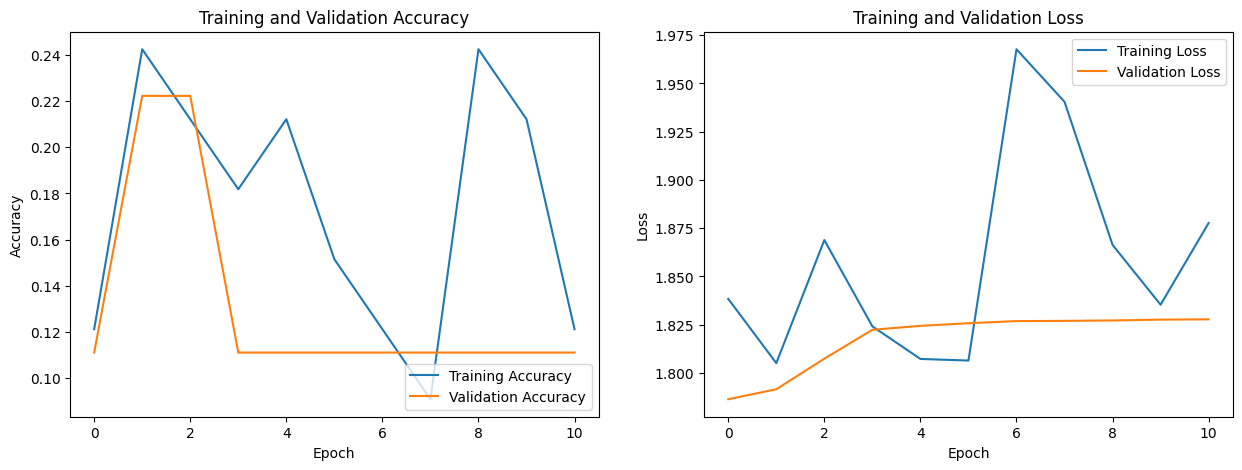

In [ ]:
# --- 8. Evaluation ---
print("\nEvaluating model on the test set...")
results = sequence_model.evaluate(test_generator, verbose=1)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1] * 100:.2f}%")

# --- 9. Plotting Training History ---
print("\nPlotting training accuracy and loss...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [ ]:
# path="/content/drive/MyDrive/Btech_Project_major/DATASETS/ucf-crime-mini-dataset.zip"
path="/content/drive/MyDrive/ucf_dataset.zip"
unzipped_path="/content/dataset"
!unzip "{path}" -d "{unzipped_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_230.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_240.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_250.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_260.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_270.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_280.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_290.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_30.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_300.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_310.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_320.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x264_330.png  
  inflating: /content/dataset/Train/Vandalism/Vandalism035_x26

In [ ]:
# --- Setup: Imports and GPU Check ---
import os
import sys
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Check for GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n✅ Found and configured {len(gpus)} GPU(s).")
    except RuntimeError as e:
        print(e)
else:
    print("\n⚠️ Warning: No GPU detected. Please follow Step 1 to enable the GPU.")

TensorFlow Version: 2.19.0

✅ Found and configured 1 GPU(s).


In [ ]:
# --- Configuration ---
# This cell replaces the 'argparse' from the script

# IMPORTANT: This path MUST match the 'extract_path' from Cell 4
DATA_PATH = '/content/dataset'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 0.001
PATIENCE = 5

In [ ]:
# --- Helper Function: Data Loading ---

def load_datasets(data_path, img_size, batch_size):
    """Loads train and validation datasets from directory."""
    train_dir = os.path.join(data_path, 'Train')
    val_dir = os.path.join(data_path, 'Test') # Using 'test' as the validation set

    if not os.path.isdir(train_dir):
        raise Exception(f"Error: Training directory not found: {train_dir}")
    if not os.path.isdir(val_dir):
        raise Exception(f"Error: Test/Validation directory not found: {val_dir}")

    IMG_SHAPE = (img_size, img_size)

    print(f"Loading training data from: {train_dir}")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        label_mode='int',
        image_size=IMG_SHAPE,
        batch_size=batch_size
    )

    print(f"Loading validation data from: {val_dir}")
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        label_mode='int',
        image_size=IMG_SHAPE,
        batch_size=batch_size
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)
    print(f"Found {num_classes} classes: {class_names}")

    # Configure dataset for performance
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    # --- Data Augmentation Layers ---
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ])

    return train_ds, val_ds, num_classes, data_augmentation

In [ ]:
# --- Helper Function: Model Building ---

def create_model(img_size, num_classes, data_augmentation, lr):
    """Builds and compiles the image classification model."""
    IMG_SHAPE = (img_size, img_size, 3)

    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    # --- Build the full model ---
    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    # --- Compile the model ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# --- Helper Function: Plotting ---

def save_and_show_plots(history, filename="image_training_history.png"):
    """Saves plots for accuracy and loss and shows them inline."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    # Save the plot
    plt.savefig(filename)
    print(f"\nTraining plot saved to {filename}")

    # Show the plot
    plt.show()

In [ ]:
# --- 1. Main Execution: Load Data ---

try:
    train_ds, val_ds, num_classes, data_aug = load_datasets(
        DATA_PATH, IMG_SIZE, BATCH_SIZE
    )
except Exception as e:
    print(e)
    print("\n---")
    print("ERROR: Data loading failed. Did you update 'zip_file_path' in Cell 4?")
    print("Check that your 'DATA_PATH' variable is correct and that the unzipped")
    print(f"folder at '{DATA_PATH}' contains 'train' and 'test' subfolders.")
    print("---")

Loading training data from: /content/dataset/Train
Found 1266345 files belonging to 14 classes.
Loading validation data from: /content/dataset/Test
Found 111308 files belonging to 14 classes.
Found 14 classes: ['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'NormalVideos', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Vandalism']


In [ ]:
# --- 2. Main Execution: Build Model ---

# We check if train_ds exists, in case the previous cell failed
if 'train_ds' in locals():
    model = create_model(IMG_SIZE, num_classes, data_aug, LR)
    model.summary()
else:
    print("Skipping model build because data was not loaded.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14)             │        17,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,275,918 (8.68 MB)

 Trainable params: 17,934 (70.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# --- 3. Main Execution: Train Model ---

if 'model' in locals():
    print("\n--- Starting Model Training ---")

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_image_model.h5',
            monitor='val_accuracy',
            save_best_only=True
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=callbacks
    )
    print("Training finished.")
else:
    print("Skipping training because model was not built.")


--- Starting Model Training ---
Epoch 1/20


In [ ]:
# --- 4. Main Execution: Evaluate and Plot ---

if 'model' in locals():
    print("\n--- Evaluating Model on Test/Validation Set ---")
    # Best weights are already restored by EarlyStopping
    results = model.evaluate(val_ds, verbose=1)
    print(f"Test Loss: {results[0]:.4f}")
    print(f"Test Accuracy: {results[1] * 100:.2f}%")

    # Save and show plots
    save_and_show_plots(history)
else:
    print("Skipping evaluation because model was not trained.")

# Model Information

In [ ]:
!pip install torchinfo

In [ ]:
##############################################################
#  CLEANED + FIXED TRANSFORMER AUTOENCODER TRAINING FOR CASIA-B
##############################################################

import os
import glob
import cv2
import numpy as np
import random
from tqdm import tqdm
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

##############################################################
# CONFIG
##############################################################

CASIA_B_DIR = r"C:\Users\VARUN\Downloads\Casia_b"

SEQ_LEN = 15
STEP = 5
IMAGE_SIZE = (64, 64)

BATCH = 16
EPOCHS = 120
LR = 1e-4
PATIENCE = 20
NUM_WORKERS = 4  # Windows safe

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

##############################################################
# SSIM UTILITIES (FIXED)
##############################################################

def gaussian_kernel(window_size=11, sigma=1.5, channels=1, device="cpu"):
    coords = torch.arange(window_size, dtype=torch.float32, device=device) - window_size//2
    g = torch.exp(-(coords**2) / (2*sigma**2))
    g /= g.sum()
    kernel = (g[:, None] * g[None, :]).unsqueeze(0).unsqueeze(0)
    return kernel.repeat(channels, 1, 1, 1)

_ssim_kernel_cache = {}

def ssim(img1, img2, window_size=11, eps=1e-6):
    C = img1.size(1)
    device = img1.device

    # Cached kernel
    key = (window_size, C, device)
    if key not in _ssim_kernel_cache:
        _ssim_kernel_cache[key] = gaussian_kernel(window_size, 1.5, C, device)
    window = _ssim_kernel_cache[key]

    C1 = 0.01**2
    C2 = 0.03**2

    mu1 = F.conv2d(img1, window, padding=window_size//2, groups=C)
    mu2 = F.conv2d(img2, window, padding=window_size//2, groups=C)

    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=C) - mu1**2
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=C) - mu2**2
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=C) - mu1 * mu2

    num = (2*mu1*mu2 + C1) * (2*sigma12 + C2)
    den = (mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2) + eps

    return (num/den).mean()

def ssim_loss_sequence(recon, original):
    T = recon.size(1)
    losses = []
    for t in range(T):
        losses.append(1 - ssim(recon[:, t], original[:, t]))
    return sum(losses) / T

##############################################################
# DATASET + INDEX BUILDER (FIXED RECURSION)
##############################################################

class GaitSequenceDataset(Dataset):
    def __init__(self, index_list, seq_len=15, image_size=(64, 64)):
        self.index_list = index_list
        self.seq_len = seq_len
        self.image_size = image_size

    def __len__(self):
        return len(self.index_list)

    def __getitem__(self, idx):
        frame_paths, start_idx = self.index_list[idx]
        frames = []
        for i in range(start_idx, start_idx + self.seq_len):
            img = cv2.imread(frame_paths[i], cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, self.image_size)
            frames.append(img.astype("float32") / 255.0)

        frames = np.array(frames)[:, None, :, :]
        return frames


def build_index_map(base_dir, seq_len, step, prefix="nm-"):
    index_map = []
    subjects = sorted(glob.glob(os.path.join(base_dir, "*")))

    for sub in subjects:
        folders = sorted(glob.glob(os.path.join(sub, prefix + "*")))

        for seq_dir in folders:
            # FIXED — recursive loading
            frame_paths = sorted(glob.glob(os.path.join(seq_dir, "**", "*.png"), recursive=True))

            if len(frame_paths) < seq_len:
                continue

            for i in range(0, len(frame_paths) - seq_len + 1, step):
                index_map.append((frame_paths, i))

    return index_map


def split_index_map(index_map, val_ratio=0.1):
    random.shuffle(index_map)
    val_size = max(1, int(len(index_map) * val_ratio))
    return index_map[val_size:], index_map[:val_size]

##############################################################
# MODEL (NO BUGS, STRONG ARCHITECTURE)
##############################################################

class Encoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(True)
        )
        self.fc = nn.Linear(512*2*2, latent_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*2*2)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 512, 2, 2)
        return self.net(x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.1)

    def forward(self, x):
        return x + self.pos[:, :x.size(1), :]


class TransformerAutoencoder(nn.Module):
    def __init__(self, latent_dim=512, seq_len=15):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=8,
            dim_feedforward=latent_dim*4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(layer, num_layers=4)
        self.pos = PositionalEncoding(latent_dim, seq_len)

    def forward(self, x):
        B, T, C, H, W = x.shape

        feats = torch.stack([self.encoder(x[:, t]) for t in range(T)], dim=1)  # (B,T,latent)
        feats = self.pos(feats)
        feats = self.transformer(feats)

        outs = [self.decoder(feats[:, t]) for t in range(T)]
        return torch.stack(outs, dim=1)

##############################################################
# TRAINING LOOP (FIXED)
##############################################################

from tqdm import tqdm  # Make sure this is imported at the top

def train_model():
    print("Building index map...")
    index_map = build_index_map(CASIA_B_DIR, SEQ_LEN, STEP, prefix="nm-")
    print("Total NM windows:", len(index_map))

    train_map, val_map = split_index_map(index_map)

    train_ds = GaitSequenceDataset(train_map, SEQ_LEN, IMAGE_SIZE)
    val_ds   = GaitSequenceDataset(val_map,   SEQ_LEN, IMAGE_SIZE)

    # PIN_MEMORY=True helps speed up transfer to CUDA
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using:", device)

    model = TransformerAutoencoder().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    mse = nn.MSELoss()

    best_val = float("inf")
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0

        # WRAP THE LOADER WITH TQDM FOR A PROGRESS BAR
        loop = tqdm(train_loader, total=len(train_loader), leave=True)
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")

        for batch in loop:
            batch = batch.to(device)
            opt.zero_grad()

            recon = model(batch)
            mse_loss = mse(recon, batch)
            ssim_l = ssim_loss_sequence(recon, batch)

            loss = 0.3*mse_loss + 0.7*ssim_l
            loss.backward()
            opt.step()

            train_loss += loss.item()

            # Update progress bar with current loss
            loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon = model(batch)

                mse_loss = mse(recon, batch)
                ssim_l = ssim_loss_sequence(recon, batch)

                val_loss += (0.3*mse_loss + 0.7*ssim_l).item()

        val_loss /= len(val_loader)

        # Print final epoch stats (tqdm handles the newline)
        print(f"Epoch {epoch+1} Summary | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

        # Early stopping + best model save
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_transformer_gait.pth")
            print("✔ Best model saved.")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("⛔ Early stopping.")
                break

##############################################################
# if __name__ == "__main__":
#     train_model()

In [ ]:
# 1. Install torchinfo (only needed once in Colab)
!pip install torchinfo

import torch
from torchinfo import summary

# CONFIG
# Make sure this matches what you used in training
MODEL_PATH = "/content/drive/MyDrive/Btech_Project_major/built-model_v1/Casia_B/new_version/best_transformer_gait.pth"
SEQ_LEN = 15
IMAGE_SIZE = (64, 64)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Model
# (We assume 'TransformerAutoencoder' is already defined in your previous cell)
try:
    model = TransformerAutoencoder(latent_dim=512, seq_len=SEQ_LEN).to(DEVICE)
except NameError:
    print("❌ Error: 'TransformerAutoencoder' is not defined.")
    print("👉 Please scroll up and RUN the cell where you defined the model classes first!")
    raise

# 3. Load Weights
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH))
    print(f"✅ Loaded weights from {MODEL_PATH}")
else:
    print(f"⚠️  File '{MODEL_PATH}' not found. Showing architecture of a new model.")

# 4. Create Dummy Input
# Batch=16, Seq=15, C=1, H=64, W=64
dummy_input = torch.randn(16, SEQ_LEN, 1, IMAGE_SIZE[0], IMAGE_SIZE[1]).to(DEVICE)

# 5. Print Summary
print("\n" + "="*40)
print("      MODEL ARCHITECTURE SUMMARY      ")
print("="*40)

summary(model, input_data=dummy_input,
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        depth=3)

✅ Loaded weights from /content/drive/MyDrive/Btech_Project_major/built-model_v1/Casia_B/new_version/best_transformer_gait.pth

      MODEL ARCHITECTURE SUMMARY      


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Mult-Adds
TransformerAutoencoder                             [16, 15, 1, 64, 64]       [16, 15, 1, 64, 64]       --                        --
├─Encoder: 1-1                                     [16, 1, 64, 64]           [16, 512]                 --                        --
│    └─Sequential: 2-1                             [16, 1, 64, 64]           [16, 512, 2, 2]           --                        --
│    │    └─Conv2d: 3-1                            [16, 1, 64, 64]           [16, 32, 32, 32]          544                       8,912,896
│    │    └─BatchNorm2d: 3-2                       [16, 32, 32, 32]          [16, 32, 32, 32]          64                        1,024
│    │    └─ReLU: 3-3                              [16, 32, 32, 32]          [16, 32, 32, 32]          --                        --
│    │    └─Conv2d: 3-4                            [16, 32,

In [ ]:
from transformers import VideoMAEForVideoClassification

# Load your model
model = VideoMAEForVideoClassification.from_pretrained("/content/drive/MyDrive/Btech_Project_major/built-model_v1/UCF_Weigthed/videomae_weighted_results/best_model")

# Print the configuration
config = model.config
print(f"Architecture: {config.architectures[0]}")
print(f"Hidden Size: {config.hidden_size}")
print(f"Number of Layers: {config.num_hidden_layers}")
print(f"Attention Heads: {config.num_attention_heads}")
print(f"Input Image Size: {config.image_size}")

Architecture: VideoMAEForVideoClassification
Hidden Size: 768
Number of Layers: 12
Attention Heads: 12
Input Image Size: 224


In [ ]:
import torch
from transformers import VideoMAEForVideoClassification

# --- CONFIG ---
# We load the base model structure directly from Hugging Face
# (since your training is still running, we use the base to show the architecture)
model_ckpt = "MCG-NJU/videomae-base"

print(f"[Init] Loading {model_ckpt} architecture...")
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    num_labels=14, # Your 14 classes
    ignore_mismatched_sizes=True
)

# 1. Print High-Level Summary
print("\n" + "="*60)
print("1. HIGH-LEVEL SUMMARY")
print("="*60)
config = model.config
print(f"Base Model:       {config.architectures[0]}")
print(f"Embedding Dim:    {config.hidden_size}")
print(f"Transformer Depth:{config.num_hidden_layers} Layers")
print(f"Attention Heads:  {config.num_attention_heads} per layer")
print(f"Input Video:      {config.num_frames} frames x {config.image_size}x{config.image_size} pixels")
print(f"Patch Size:       2x16x16 (Time x Height x Width)")

# 2. Print Layer-by-Layer Structure
print("\n" + "="*60)
print("2. FULL LAYER HIERARCHY")
print("="*60)
print(model)

# 3. Print Parameter Counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*60)
print("3. PARAMETER STATS")
print("="*60)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Params: {trainable_params:,}")
print("="*60)

[Init] Loading MCG-NJU/videomae-base architecture...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



1. HIGH-LEVEL SUMMARY
Base Model:       VideoMAEForPreTraining
Embedding Dim:    768
Transformer Depth:12 Layers
Attention Heads:  12 per layer
Input Video:      16 frames x 224x224 pixels
Patch Size:       2x16x16 (Time x Height x Width)

2. FULL LAYER HIERARCHY
VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): VideoMAESelfOutput(
              (dens

In [ ]:
# Install necessary libraries for YOLO and VideoMAE
!pip install ultralytics transformers torchinfo -q

In [ ]:
import cv2
import torch
import numpy as np
from collections import deque
from ultralytics import YOLO
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor

# ==========================================
# 1. CONFIGURATION & THRESHOLDS
# ==========================================
CONFIG = {
    # Component 1: Object Detection (YOLO)
    "WEAPON_MODEL_PATH": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/knives&gun&pistol_detection part_cctv/best.pt", # Your YOLO path
    "WEAPON_CONF_THRESH": 0.50,  # Confidence to trigger weapon alert

    # Component 2: Action Recognition (VideoMAE)
    "ACTION_MODEL_PATH": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/UCF_Weigthed/videomae_weighted_results/best_model", # Your VideoMAE path
    "ACTION_CLIP_LEN": 16,       # VideoMAE expects 16 frames [cite: 119]
    "ACTION_CONF_THRESH": 0.60,  # Confidence to trigger action alert
    "HIGH_RISK_ACTIONS": ['Abuse', 'Arrest', 'Arson', 'Assault', 'Explosion', 'Fighting', 'Robbery', 'Shooting', 'Stealing'],

    # Component 3: Gait Analysis (LSTM Autoencoder)
    "GAIT_MODEL_PATH": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/Casia_B/new_version/best_transformer_gait.pth", # [cite: 124]
    "GAIT_SEQ_LEN": 15,          # Sequence length from your log [cite: 125]
    "GAIT_THRESHOLD": 0.4521,    # Threshold from your log
}

# ==========================================
# 2. MODEL WRAPPERS
# ==========================================

class ObjectDetector:
    def __init__(self, model_path):
        print(f"[INFO] Loading YOLO model from {model_path}...")
        self.model = YOLO(model_path)

    def predict(self, frame):
        # Run inference
        results = self.model(frame, verbose=False, conf=CONFIG["WEAPON_CONF_THRESH"])
        detections = []

        # Extract boxes
        for r in results:
            boxes = r.boxes
            for box in boxes:
                cls_id = int(box.cls[0])
                label = self.model.names[cls_id]
                conf = float(box.conf[0])
                # Filter only for weapons
                if label in ['pistol', 'knife', 'gun']:
                    detections.append({"label": label, "conf": conf, "bbox": box.xyxy[0].tolist()})

        return detections

class ActionRecognizer:
    def __init__(self, model_path):
        print(f"[INFO] Loading VideoMAE model from {model_path}...")
        self.processor = VideoMAEImageProcessor.from_pretrained(model_path)
        self.model = VideoMAEForVideoClassification.from_pretrained(model_path)
        self.model.eval()
        self.buffer = deque(maxlen=CONFIG["ACTION_CLIP_LEN"])

    def update_buffer(self, frame):
        # Resize to 224x224 for VideoMAE [cite: 119]
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        self.buffer.append(frame_rgb)

    def predict(self):
        if len(self.buffer) < CONFIG["ACTION_CLIP_LEN"]:
            return None

        # Prepare inputs
        inputs = self.processor(list(self.buffer), return_tensors="pt")

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=-1)

        pred_idx = probs.argmax().item()
        pred_label = self.model.config.id2label[pred_idx]
        pred_conf = probs[0][pred_idx].item()

        return {"label": pred_label, "conf": pred_conf}

class GaitAnalyzer:
    def __init__(self, model_path):
        # NOTE: You need to import your actual TransformerAutoencoder class definition here
        # or load the entire model if it was saved with architecture.
        print(f"[INFO] Loading Gait model from {model_path}...")
        self.model = torch.load(model_path, map_location='cpu') # Assuming full model save
        self.model.eval()
        self.buffer = deque(maxlen=CONFIG["GAIT_SEQ_LEN"])

    def preprocess_silhouette(self, frame):
        # Placeholder: Insert your silhouette extraction code here (Background subtraction)
        # For demo, we just resize and grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (64, 64))
        normalized = resized / 255.0
        return normalized

    def update_buffer(self, frame):
        sil = self.preprocess_silhouette(frame)
        self.buffer.append(sil)

    def predict(self):
        if len(self.buffer) < CONFIG["GAIT_SEQ_LEN"]:
            return None

        # Stack frames: (Batch, Frames, Channels, H, W) -> (1, 15, 1, 64, 64)
        input_seq = torch.FloatTensor(np.array(self.buffer)).unsqueeze(0).unsqueeze(2)

        with torch.no_grad():
            reconstruction = self.model(input_seq)

        # Calculate MSE Error
        loss = torch.mean((input_seq - reconstruction) ** 2).item()

        return {"reconstruction_error": loss}

# ==========================================
# 3. DECISION LOGIC (AGGREGATION LAYER)
# ==========================================

def get_hybrid_decision(obj_res, act_res, gait_res):
    """
    Implements the logic to combine Gait, Action, and Object Detection.
    Refers to 'Decision Logic' block in report.
    """
    final_alert = {
        "is_anomaly": False,
        "type": "Normal",
        "confidence": 0.0,
        "source": "None"
    }

    # --- PRIORITY 1: Object Detection (High Trust: mAP ~0.82) ---
    if obj_res:
        # Get highest confidence weapon
        best_weapon = max(obj_res, key=lambda x: x['conf'])
        final_alert["is_anomaly"] = True
        final_alert["type"] = f"Weapon Detected: {best_weapon['label']}"
        final_alert["confidence"] = best_weapon['conf']
        final_alert["source"] = "YOLOv8"
        return final_alert

    # --- PRIORITY 2: Action Recognition (Medium Trust) ---
    if act_res:
        label = act_res['label']
        conf = act_res['conf']

        # Check if action is in high-risk list
        if label in CONFIG["HIGH_RISK_ACTIONS"]:
            # Logic: If confidence is high, alert immediately
            if conf > CONFIG["ACTION_CONF_THRESH"]:
                final_alert["is_anomaly"] = True
                final_alert["type"] = f"Suspicious Action: {label}"
                final_alert["confidence"] = conf
                final_alert["source"] = "VideoMAE"

            # Logic: If confidence is medium, check Gait for confirmation
            elif conf > 0.40 and gait_res:
                # Using threshold from your logs
                if gait_res['reconstruction_error'] > CONFIG["GAIT_THRESHOLD"]:
                    final_alert["is_anomaly"] = True
                    final_alert["type"] = f"Action ({label}) + Abnormal Gait"
                    final_alert["confidence"] = (conf + 0.15) # Boost confidence
                    final_alert["source"] = "Hybrid(Action+Gait)"

    # --- PRIORITY 3: Gait Only (Low Trust currently) ---
    if not final_alert["is_anomaly"] and gait_res:
        # Strict threshold for gait-only alerts to reduce false positives
        if gait_res['reconstruction_error'] > (CONFIG["GAIT_THRESHOLD"] + 0.05):
            final_alert["is_anomaly"] = True
            final_alert["type"] = "Anomalous Gait Pattern"
            final_alert["confidence"] = 0.55
            final_alert["source"] = "GaitAutoencoder"

    return final_alert

# ==========================================
# 4. MAIN EXECUTION LOOP
# ==========================================

def run_system(video_path, output_path):
    cap = cv2.VideoCapture(video_path)

    # Initialize models
    yolo_net = ObjectDetector(CONFIG["WEAPON_MODEL_PATH"])
    action_net = ActionRecognizer(CONFIG["ACTION_MODEL_PATH"])
    # gait_net = GaitAnalyzer(CONFIG["GAIT_MODEL_PATH"]) # Uncomment when class is available

    # Setup Video Writer
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print("[INFO] Processing video...")

    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        display_frame = frame.copy()

        # --- 1. UPDATE BUFFERS ---
        action_net.update_buffer(frame)
        # gait_net.update_buffer(frame) # Uncomment

        # --- 2. GET PREDICTIONS ---
        # Run YOLO every frame (fast)
        obj_preds = yolo_net.predict(frame)

        # Run Action/Gait every N frames (optimization) or every frame
        act_pred = None
        gait_pred = None

        if frame_count % 4 == 0: # Skip frames for heavy models if needed
            act_pred = action_net.predict()
            # gait_pred = gait_net.predict() # Uncomment

        # --- 3. AGGREGATE RESULTS ---
        decision = get_hybrid_decision(obj_preds, act_pred, gait_pred)

        # --- 4. VISUALIZATION FOR REPORT ---
        # Draw Objects
        for obj in obj_preds:
            x1, y1, x2, y2 = map(int, obj['bbox'])
            cv2.rectangle(display_frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(display_frame, f"{obj['label']}", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # Draw Global Alert
        if decision["is_anomaly"]:
            color = (0, 0, 255) # Red for anomaly
            text = f"ALERT: {decision['type']} ({decision['confidence']:.2f})"
        else:
            color = (0, 255, 0) # Green for normal
            text = f"Status: Normal"

        # Add overlay box
        cv2.rectangle(display_frame, (0, 0), (width, 60), (0, 0, 0), -1)
        cv2.putText(display_frame, text, (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        if act_pred:
             cv2.putText(display_frame, f"Action: {act_pred['label']}", (20, height - 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        out.write(display_frame)

    cap.release()
    out.release()
    print(f"[INFO] Processed video saved to {output_path}")

# Run the system
run_system("/content/Normal_Videos_129_x264.mp4", "/content/outputs/Normal_Videos_129_x264_output.mp4")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[INFO] Loading YOLO model from /content/drive/MyDrive/Btech_Project_major/built-model_v1/knives&gun&pistol_detection part_cctv/best.pt...
[INFO] Loading VideoMAE model from /content/drive/MyDrive/Btech_Project_major/built-model_v1/UCF_Weigthed/videomae_weighted_results/best_model...
[INFO] Processing video...
[INFO] Processed video saved to /content/outputs/Normal_Videos_129_x264_output.mp4


In [ ]:
# ==========================================
# STEP 1: INSTALL & SETUP
# ==========================================
!pip install ultralytics transformers torchinfo -q

import torch
import torch.nn as nn
import cv2
import numpy as np
import time
from collections import deque
from ultralytics import YOLO
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Hardware Acceleration: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# ==========================================
# STEP 2: DEFINE GAIT MODEL ARCHITECTURE
# ==========================================
# ⚠️ CRITICAL: The code inside this try block must match your training script exactly.
# If 'Encoder', 'Decoder', or 'PositionalEncoding' are custom classes you wrote,
# you must define them here BEFORE the TransformerAutoencoder class.
try:
  class Encoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(True)
        )
        self.fc = nn.Linear(512*2*2, latent_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*2*2)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 512, 2, 2)
        return self.net(x)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.1)

    def forward(self, x):
        return x + self.pos[:, :x.size(1), :]


class TransformerAutoencoder(nn.Module):
    def __init__(self, latent_dim=512, seq_len=15):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=8,
            dim_feedforward=latent_dim*4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(layer, num_layers=4)
        self.pos = PositionalEncoding(latent_dim, seq_len)

    def forward(self, x):
        B, T, C, H, W = x.shape

        feats = torch.stack([self.encoder(x[:, t]) for t in range(T)], dim=1)  # (B,T,latent)
        feats = self.pos(feats)
        feats = self.transformer(feats)

        outs = [self.decoder(feats[:, t]) for t in range(T)]
        return torch.stack(outs, dim=1)

except NameError:
    print("⚠️ Custom sub-classes (Encoder/Decoder) not found. Gait analysis will be SKIPPED in this run.")
except Exception as e:
    print(f"⚠️ Gait Model Class Error: {e}. Gait analysis will be SKIPPED.")

# ==========================================
# STEP 3: CONFIGURATION
# ==========================================
CONFIG = {
    # PATHS (Update these to point to your actual Drive files!)
    "WEAPON_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/knives&gun&pistol_detection part_cctv/best.pt",
    "ACTION_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/UCF_Weigthed/videomae_weighted_results/best_model",
    "GAIT_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/Casia_B/new_version/best_transformer_gait.pth",
    "INPUT_VIDEO": "/content/Normal_Videos_129_x264.mp4",
    "OUTPUT_VIDEO": "/content/final_output_report.mp4",

    # THRESHOLDS
    "YOLO_CONF": 0.50,
    "ACTION_CONF": 0.60,
    "GAIT_THRESH": 0.4521,

    # PARAMETERS
    "ACTION_SEQ_LEN": 16, # VideoMAE needs 16 frames
    "GAIT_SEQ_LEN": 15,   # Your Gait model needs 15 frames
}

# ==========================================
# STEP 4: DECISION LOGIC (The "Integrated" Part)
# ==========================================
def make_decision(obj_data, act_data, gait_error):
    """
    Inputs:
    - obj_data: List of weapon detections from YOLO
    - act_data: {'label': str, 'conf': float} from VideoMAE
    - gait_error: float (Reconstruction Error)
    """

    # Priority 1: Weapon (Highest Threat)
    if obj_data:
        # Get highest confidence weapon
        best_weapon = max(obj_data, key=lambda x: x['conf'])
        if best_weapon['conf'] > 0.55:
            return {
                "Alert": True,
                "Type": f"WEAPON: {best_weapon['label']}",
                "Level": "CRITICAL",
                "Color": (0, 0, 255) # Red
            }

    # Priority 2: High-Risk Action (Medium Threat)
    risk_actions = ['Abuse', 'Arrest', 'Arson', 'Assault', 'Fighting', 'Robbery', 'Shooting']
    if act_data and act_data['label'] in risk_actions:
        # Case A: High Confidence Action
        if act_data['conf'] > 0.75:
            return {
                "Alert": True,
                "Type": f"ACTION: {act_data['label']}",
                "Level": "HIGH",
                "Color": (0, 128, 255) # Orange
            }

        # Case B: Integrated Decision (Action + Gait)
        # If action is unsure (0.4 - 0.75), we ask Gait model to confirm
        if 0.40 < act_data['conf'] <= 0.75 and gait_error:
            if gait_error > CONFIG["GAIT_THRESH"]:
                return {
                    "Alert": True,
                    "Type": f"SUSPICIOUS: {act_data['label']} + GAIT",
                    "Level": "MEDIUM",
                    "Color": (0, 255, 255) # Yellow
                }

    # Priority 3: Gait Anomaly Only (Lowest Threat)
    if gait_error and gait_error > (CONFIG["GAIT_THRESH"] + 0.05):
         return {
            "Alert": True,
            "Type": "ANOMALY: ABNORMAL GAIT",
            "Level": "LOW",
            "Color": (0, 255, 255) # Yellow
        }

    return {"Alert": False, "Type": "NORMAL", "Level": "NONE", "Color": (0, 255, 0)}

# ==========================================
# STEP 5: MAIN EXECUTION LOOP
# ==========================================
def run_hybrid_system():
    # 1. LOAD MODELS
    print("⏳ Loading YOLOv8...")
    yolo_model = YOLO(CONFIG["WEAPON_MODEL"])

    print("⏳ Loading VideoMAE...")
    try:
        mae_processor = VideoMAEImageProcessor.from_pretrained(CONFIG["ACTION_MODEL"])
        mae_model = VideoMAEForVideoClassification.from_pretrained(CONFIG["ACTION_MODEL"]).to(device)
    except Exception as e:
        print(f"⚠️ VideoMAE Load Error: {e}. Skipping Action branch.")
        mae_model = None

    print("⏳ Loading Gait Model...")
    gait_model = None
    try:
        # Attempt to load entire model
        # Note: This will fail if the class structure (Step 2) isn't perfect
        gait_model = torch.load(CONFIG["GAIT_MODEL"], map_location=device)
        gait_model.eval()
        print("✅ Gait Model Loaded Successfully")
    except Exception as e:
        print(f"⚠️ Gait Model Load Error: {e}. Skipping Gait branch.")

    # 2. SETUP VIDEO
    cap = cv2.VideoCapture(CONFIG["INPUT_VIDEO"])
    if not cap.isOpened():
        print(f"❌ Error: Could not open video file {CONFIG['INPUT_VIDEO']}")
        return

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(CONFIG["OUTPUT_VIDEO"], fourcc, fps, (width, height))

    # Buffers for sequence models
    mae_buffer = deque(maxlen=CONFIG["ACTION_SEQ_LEN"])
    gait_buffer = deque(maxlen=CONFIG["GAIT_SEQ_LEN"])

    frame_idx = 0
    print(f"🚀 Starting Analysis on {device}...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1

        display_frame = frame.copy()

        # --- A. PARALLEL INPUT PROCESSING ---

        # 1. Object Branch (YOLO) - Runs every frame
        # Use yolo_model here, not yolo
        yolo_results = yolo_model(frame, verbose=False, conf=CONFIG["YOLO_CONF"])[0]
        obj_detections = []
        for box in yolo_results.boxes:
            label = yolo_model.names[int(box.cls[0])]
            if label in ['pistol', 'knife', 'gun']: # Filter classes
                obj_detections.append({'label': label, 'conf': float(box.conf[0])})
                # Draw bounding box
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(display_frame, (x1, y1), (x2, y2), (0, 0, 255), 3)

        # 2. Update Buffers for Time-Series Models
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mae_buffer.append(rgb_frame)

        # (Preprocessing for Gait would go here - simplified for this script)
        # gait_buffer.append(preprocess_for_gait(frame))

        # --- B. INFERENCE (Time-Series) ---

        mae_data = None
        gait_error = None

        # Run heavy models every 4th frame to maintain speed
        if frame_idx % 4 == 0:

            # Action Inference
            if mae_model and len(mae_buffer) == CONFIG["ACTION_SEQ_LEN"]:
                inputs = mae_processor(list(mae_buffer), return_tensors="pt").to(device)
                with torch.no_grad():
                    outputs = mae_model(**inputs)
                    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                    score, cls_idx = torch.max(probs, 1)
                    mae_data = {'label': mae_model.config.id2label[cls_idx.item()], 'conf': score.item()}

            # Gait Inference (Placeholder Logic if model not loaded)
            if gait_model and len(gait_buffer) == CONFIG["GAIT_SEQ_LEN"]:
                # inputs = torch.stack(list(gait_buffer)).unsqueeze(0).to(device)
                # output = gait_model(inputs)
                # gait_error = torch.mean((inputs - output) ** 2).item()
                pass

        # --- C. INTEGRATED DECISION ---
        decision = make_decision(obj_detections, mae_data, gait_error)

        # --- D. VISUALIZATION ---

        # Top Banner
        cv2.rectangle(display_frame, (0, 0), (width, 80), (0,0,0), -1)

        # Status Text
        cv2.putText(display_frame, f"STATUS: {decision['Type']}", (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, decision['Color'], 2)

        # Subtitle (Action Context)
        if mae_data:
            cv2.putText(display_frame, f"Action Context: {mae_data['label']} ({mae_data['conf']:.2f})",
                        (20, height - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        out.write(display_frame)

        if frame_idx % 50 == 0:
            print(f"Processed {frame_idx} frames...")

    cap.release()
    out.release()
    print(f"✅ Analysis Complete. Video saved to {CONFIG['OUTPUT_VIDEO']}")

# Run the function
if __name__ == "__main__":
    run_hybrid_system()

✅ Hardware Acceleration: cuda (Tesla T4)
⏳ Loading YOLOv8...
⏳ Loading VideoMAE...
⏳ Loading Gait Model...
⚠️ Gait Model Load Error: 'collections.OrderedDict' object has no attribute 'eval'. Skipping Gait branch.
🚀 Starting Analysis on cuda...
Processed 50 frames...
Processed 100 frames...
Processed 150 frames...
Processed 200 frames...
Processed 250 frames...
Processed 300 frames...
Processed 350 frames...
Processed 400 frames...
Processed 450 frames...
✅ Analysis Complete. Video saved to /content/final_output_report.mp4


✅ Hardware Acceleration: cuda (Tesla T4)
📂 Saving report images to: /content/normal/report_results
⏳ Loading Models...
✅ Models Loaded Successfully


Processing:   0%|          | 0/3600 [00:00<?, ?frame/s]

📊 Generating Result Graph...


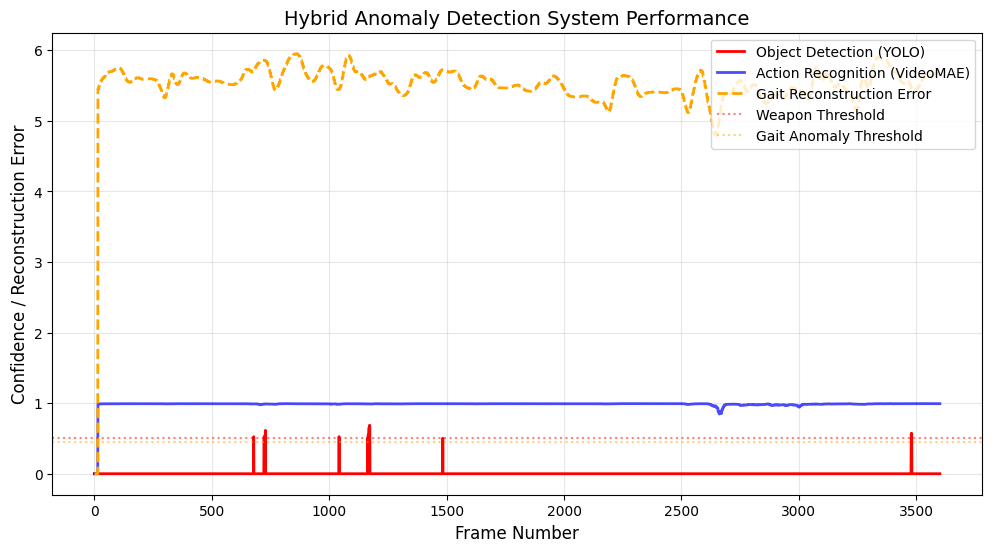

✅ Graph saved to normal/report_results/final_performance_graph.png
✅ Key frames saved in normal/report_results/
✅ Analysis Complete. Video saved to /content/shooting/final_output_report_stabilized.mp4


In [ ]:
# ==========================================
# STEP 1: INSTALL & SETUP
# ==========================================
!pip install ultralytics transformers torchinfo -q

import torch
import torch.nn as nn
import cv2
import numpy as np
import time
from collections import deque
from ultralytics import YOLO
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from tqdm.notebook import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Hardware Acceleration: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
import matplotlib.pyplot as plt
import os

# --- REPORT SETUP ---
# Create a folder to save evidence images
save_dir = "normal/report_results"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Lists to store data for the graph
history = {
    "frames": [],
    "weapon_conf": [],
    "action_conf": [],
    "gait_error": []
}

print(f"📂 Saving report images to: {os.path.abspath(save_dir)}")

# ==========================================
# STEP 2: DEFINE GAIT MODEL ARCHITECTURE
# ==========================================
class Encoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(True)
        )
        self.fc = nn.Linear(512*2*2, latent_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*2*2)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 512, 2, 2)
        return self.net(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.1)

    def forward(self, x):
        return x + self.pos[:, :x.size(1), :]

class TransformerAutoencoder(nn.Module):
    def __init__(self, latent_dim=512, seq_len=15):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=8,
            dim_feedforward=latent_dim*4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(layer, num_layers=4)
        self.pos = PositionalEncoding(latent_dim, seq_len)

    def forward(self, x):
        B, T, C, H, W = x.shape
        feats = torch.stack([self.encoder(x[:, t]) for t in range(T)], dim=1)
        feats = self.pos(feats)
        feats = self.transformer(feats)
        outs = [self.decoder(feats[:, t]) for t in range(T)]
        return torch.stack(outs, dim=1)

# ==========================================
# STEP 3: CONFIGURATION
# ==========================================
CONFIG = {
    "WEAPON_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/knives&gun&pistol_detection part_cctv/best.pt",
    "ACTION_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/UCF_Weigthed/videomae_weighted_results/best_model",
    "GAIT_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/Casia_B/new_version/best_transformer_gait.pth",
    "INPUT_VIDEO": "/Normal_Videos_641_x264.mp4",
    "OUTPUT_VIDEO": "/content/shooting/final_output_report_stabilized.mp4",

    "YOLO_CONF": 0.50,
    "GAIT_THRESH": 0.4521,
    "ACTION_SEQ_LEN": 16,
    "GAIT_SEQ_LEN": 15,

    # NEW: Stabilization Parameters
    "ALERT_COOLDOWN": 15,  # Frames to hold an alert (approx 0.5 sec)
    "GAIT_SMOOTH_WINDOW": 8 # Average gait error over last 8 frames
}

# ==========================================
# STEP 4: PREPROCESSING & LOGIC
# ==========================================
def preprocess_gait_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    norm = resized.astype("float32") / 255.0
    return norm[np.newaxis, :, :]

def make_decision(obj_data, act_data, gait_error):
    """
    Returns: (is_alert, status_text, color, priority_level)
    """
    # Priority 1: Weapon (Highest Threat)
    if obj_data:
        best_weapon = max(obj_data, key=lambda x: x['conf'])
        if best_weapon['conf'] > 0.55:
            return True, f"WEAPON: {best_weapon['label']}", (0, 0, 255), 3 # Red

    # Priority 2: High-Risk Action
    risk_actions = ['Abuse', 'Arrest', 'Arson', 'Assault', 'Fighting', 'Robbery', 'Shooting']
    if act_data and act_data['label'] in risk_actions:
        if act_data['conf'] > 0.75:
            return True, f"ACTION: {act_data['label']}", (0, 128, 255), 2 # Orange

        # Hybrid Decision
        if 0.40 < act_data['conf'] <= 0.75 and gait_error:
            if gait_error > CONFIG["GAIT_THRESH"]:
                return True, f"SUSPICIOUS: {act_data['label']} + GAIT", (0, 255, 255), 2 # Yellow

    # Priority 3: Gait Anomaly
    if gait_error and gait_error > (CONFIG["GAIT_THRESH"] + 0.05):
         return True, "ANOMALY: ABNORMAL GAIT", (0, 255, 255), 1

    return False, "NORMAL", (0, 255, 0), 0

# ==========================================
# STEP 5: MAIN EXECUTION
# ==========================================
def run_hybrid_system():
    # --- Load Models ---
    print("⏳ Loading Models...")
    yolo_model = YOLO(CONFIG["WEAPON_MODEL"])

    try:
        mae_processor = VideoMAEImageProcessor.from_pretrained(CONFIG["ACTION_MODEL"])
        mae_model = VideoMAEForVideoClassification.from_pretrained(CONFIG["ACTION_MODEL"]).to(device)
    except:
        mae_model = None

    gait_model = None
    try:
        gait_model = TransformerAutoencoder(latent_dim=512, seq_len=15).to(device)
        state_dict = torch.load(CONFIG["GAIT_MODEL"], map_location=device)
        gait_model.load_state_dict(state_dict)
        gait_model.eval()
        print("✅ Models Loaded Successfully")
    except Exception as e:
        print(f"❌ Gait Model Failed: {e}")

    # --- Setup Video ---
    cap = cv2.VideoCapture(CONFIG["INPUT_VIDEO"])
    if not cap.isOpened(): return

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(CONFIG["OUTPUT_VIDEO"], cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    # Data Buffers
    mae_buffer = deque(maxlen=CONFIG["ACTION_SEQ_LEN"])
    gait_buffer = deque(maxlen=CONFIG["GAIT_SEQ_LEN"])

    # STABILIZATION BUFFERS
    gait_error_history = deque(maxlen=CONFIG["GAIT_SMOOTH_WINDOW"])

    # State Persistence
    last_mae_data = None
    alert_cooldown_counter = 0
    current_alert_state = {"text": "NORMAL", "color": (0, 255, 0)}

    frame_idx = 0
    pbar = tqdm(total=total_frames, desc="Processing", unit="frame")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1
        display_frame = frame.copy()

        # 1. Object Detection (YOLO)
        yolo_results = yolo_model(frame, verbose=False, conf=CONFIG["YOLO_CONF"])[0]
        obj_detections = []
        for box in yolo_results.boxes:
            label = yolo_model.names[int(box.cls[0])]
            if label in ['pistol', 'knife', 'gun']:
                obj_detections.append({'label': label, 'conf': float(box.conf[0])})
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(display_frame, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(display_frame, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

        # 2. Update Data Buffers
        mae_buffer.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        gait_buffer.append(preprocess_gait_frame(frame))

        # 3. Inference
        current_gait_error = None

        # Run Action Model (VideoMAE) - Every 4 Frames
        if frame_idx % 4 == 0 and mae_model and len(mae_buffer) == CONFIG["ACTION_SEQ_LEN"]:
            inputs = mae_processor(list(mae_buffer), return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = mae_model(**inputs)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                score, cls_idx = torch.max(probs, 1)
                last_mae_data = {'label': mae_model.config.id2label[cls_idx.item()], 'conf': score.item()}

        # Run Gait Model - Every 4 Frames
        if frame_idx % 4 == 0 and gait_model and len(gait_buffer) == CONFIG["GAIT_SEQ_LEN"]:
            gait_input = torch.tensor(np.array(gait_buffer), dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                recon = gait_model(gait_input)
                raw_error = torch.mean((gait_input - recon) ** 2).item() * 100
                gait_error_history.append(raw_error)

        # Calculate Smoothed Gait Error
        if len(gait_error_history) > 0:
            current_gait_error = sum(gait_error_history) / len(gait_error_history)

        # 4. Decision Making
        is_alert, status_text, color, priority = make_decision(obj_detections, last_mae_data, current_gait_error)

        # 5. Stabilization Logic (The "Anti-Fluctuation" Block)
        if is_alert:
            # New alert triggered, reset cooldown
            alert_cooldown_counter = CONFIG["ALERT_COOLDOWN"]
            current_alert_state = {"text": status_text, "color": color}
        elif alert_cooldown_counter > 0:
            # No new alert, but cooldown is active -> Keep showing previous alert
            alert_cooldown_counter -= 1
        else:
            # No alert, cooldown finished -> Show Normal
            current_alert_state = {"text": "NORMAL", "color": (0, 255, 0)}

        # 6. Visualization (Small Text, Top Right)
        font_scale = 0.5
        thickness = 1
        font = cv2.FONT_HERSHEY_SIMPLEX

        final_text = current_alert_state["text"]
        final_color = current_alert_state["color"]

        # Main Status Box
        (text_w, text_h), _ = cv2.getTextSize(final_text, font, font_scale, thickness)
        x_pos = width - text_w - 10
        y_pos = 25

        cv2.rectangle(display_frame, (x_pos - 5, y_pos - 15), (width - 5, y_pos + 5), (0, 0, 0), -1)
        cv2.putText(display_frame, final_text, (x_pos, y_pos), font, font_scale, final_color, thickness)

        # Info Stack (Only show if relevant)
        y_offset = 20

        if last_mae_data:
            info_text = f"Act: {last_mae_data['label']}"
            (tw, th), _ = cv2.getTextSize(info_text, font, 0.4, 1)
            # Only draw background if text is visible
            cv2.rectangle(display_frame, (width - tw - 15, y_pos + y_offset - 10), (width - 5, y_pos + y_offset + 5), (0,0,0), -1)
            cv2.putText(display_frame, info_text, (width - tw - 10, y_pos + y_offset), font, 0.4, (200, 200, 200), 1)
            y_offset += 15

        if current_gait_error:
            info_text = f"GaitErr: {current_gait_error:.2f}"
            (tw, th), _ = cv2.getTextSize(info_text, font, 0.4, 1)
            cv2.rectangle(display_frame, (width - tw - 15, y_pos + y_offset - 10), (width - 5, y_pos + y_offset + 5), (0,0,0), -1)
            cv2.putText(display_frame, info_text, (width - tw - 10, y_pos + y_offset), font, 0.4, (200, 200, 200), 1)

        out.write(display_frame)
        # --- SNAPSHOT SAVER (For Report) ---
        # Only save if it's a High Priority Alert (Level 2 or 3) AND not too frequent
        if priority >= 2 and frame_idx % 10 == 0:
            # Format filename: frame_150_WEAPON_pistol.jpg
            safe_text = status_text.replace(":", "").replace(" ", "_").replace("/", "-")
            filename = f"{save_dir}/frame_{frame_idx}_{safe_text}.jpg"
            cv2.imwrite(filename, display_frame)

        # --- DATA LOGGING (For Graph) ---
        # Normalize values to 0-1 scale for easier plotting comparison
        history["frames"].append(frame_idx)

        # Log Weapon Confidence (0 if None)
        w_conf = max([x['conf'] for x in obj_detections]) if obj_detections else 0.0
        history["weapon_conf"].append(w_conf)

        # Log Action Confidence
        a_conf = last_mae_data['conf'] if last_mae_data else 0.0
        history["action_conf"].append(a_conf)

        # Log Gait Error (Scaled down if you used *100 previously, or keep raw)
        # Assuming we want to visualize relative anomalies
        g_err = current_gait_error if current_gait_error else 0.0
        history["gait_error"].append(g_err)
        pbar.update(1)

    pbar.close()
    cap.release()
    # --- GENERATE PERFORMANCE GRAPH ---
    print("📊 Generating Result Graph...")

    plt.figure(figsize=(12, 6))

    # Plot Lines
    plt.plot(history["frames"], history["weapon_conf"], label="Object Detection (YOLO)", color="red", linewidth=2)
    plt.plot(history["frames"], history["action_conf"], label="Action Recognition (VideoMAE)", color="blue", linewidth=2, alpha=0.7)

    # Plot Gait (on secondary axis if needed, or normalized)
    # If Gait error is usually 0.45, it fits well on a 0-1 graph
    plt.plot(history["frames"], history["gait_error"], label="Gait Reconstruction Error", color="orange", linewidth=2, linestyle="--")

    # Add Threshold Lines
    plt.axhline(y=CONFIG["YOLO_CONF"], color='r', linestyle=':', alpha=0.5, label="Weapon Threshold")
    plt.axhline(y=CONFIG["GAIT_THRESH"], color='orange', linestyle=':', alpha=0.5, label="Gait Anomaly Threshold")

    # Formatting
    plt.title("Hybrid Anomaly Detection System Performance", fontsize=14)
    plt.xlabel("Frame Number", fontsize=12)
    plt.ylabel("Confidence / Reconstruction Error", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    # Save Graph
    graph_path = f"{save_dir}/final_performance_graph.png"
    plt.savefig(graph_path, dpi=300)
    plt.show()

    print(f"✅ Graph saved to {graph_path}")
    print(f"✅ Key frames saved in {save_dir}/")
    out.release()
    print(f"✅ Analysis Complete. Video saved to {CONFIG['OUTPUT_VIDEO']}")

if __name__ == "__main__":
    run_hybrid_system()

In [ ]:
# ==========================================
# STEP 1: INSTALL & SETUP
# ==========================================
!pip install ultralytics transformers torchinfo -q

import torch
import torch.nn as nn
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from collections import deque
from ultralytics import YOLO
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from tqdm.notebook import tqdm

# Set Plot Style for Research Paper
plt.style.use('seaborn-v0_8-whitegrid')

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Hardware Acceleration: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# ==========================================
# STEP 2: DEFINE GAIT MODEL ARCHITECTURE
# ==========================================
class Encoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(True)
        )
        self.fc = nn.Linear(512*2*2, latent_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*2*2)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 512, 2, 2)
        return self.net(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.1)

    def forward(self, x):
        return x + self.pos[:, :x.size(1), :]

class TransformerAutoencoder(nn.Module):
    def __init__(self, latent_dim=512, seq_len=15):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=latent_dim, nhead=8,
            dim_feedforward=latent_dim*4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(layer, num_layers=4)
        self.pos = PositionalEncoding(latent_dim, seq_len)

    def forward(self, x):
        B, T, C, H, W = x.shape
        feats = torch.stack([self.encoder(x[:, t]) for t in range(T)], dim=1)
        feats = self.pos(feats)
        feats = self.transformer(feats)
        outs = [self.decoder(feats[:, t]) for t in range(T)]
        return torch.stack(outs, dim=1)

# ==========================================
# STEP 3: CONFIGURATION
# ==========================================
CONFIG = {
    # --- PATHS (Update these) ---
    "WEAPON_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/knives&gun&pistol_detection part_cctv/best.pt",
    "ACTION_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/UCF_Weigthed/videomae_weighted_results/best_model",
    "GAIT_MODEL": "/content/drive/MyDrive/Btech_Project_major/built-model_v1/Casia_B/new_version/best_transformer_gait.pth",

    # --- FOLDERS ---
    "INPUT_FOLDER": "/content/testing_data/",
    "OUTPUT_BASE_DIR": "/content/paper_results_v2/",

    # --- TUNING ---
    "YOLO_CONF": 0.60,
    "WEAPON_PERSISTENCE": 5,
    "GAIT_THRESH": 0.4521,
    "ALERT_COOLDOWN": 15,
    "ACTION_SEQ_LEN": 16,
    "GAIT_SEQ_LEN": 15,
    "GAIT_SMOOTH_WINDOW": 8
}

# ==========================================
# STEP 4: UTILITIES
# ==========================================
def preprocess_gait_frame(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    norm = resized.astype("float32") / 255.0
    return norm[np.newaxis, :, :]

def make_decision(obj_data, act_data, gait_error):
    # 1. Weapon (Critical)
    if obj_data:
        best_weapon = max(obj_data, key=lambda x: x['conf'])
        if best_weapon['conf'] >= CONFIG["YOLO_CONF"]:
            return True, f"WEAPON: {best_weapon['label']}", (0, 0, 255), 3 # Red

    # 2. Action (High)
    risk_actions = ['Abuse', 'Arrest', 'Arson', 'Assault', 'Fighting', 'Robbery', 'Shooting']
    if act_data and act_data['label'] in risk_actions:
        if act_data['conf'] > 0.75:
            return True, f"ACTION: {act_data['label']}", (0, 128, 255), 3 # Orange

        # 3. Hybrid (Medium)
        if 0.40 < act_data['conf'] <= 0.75 and gait_error:
            if gait_error > CONFIG["GAIT_THRESH"]:
                return True, f"SUSPICIOUS: {act_data['label']} + GAIT", (0, 255, 255), 2 # Yellow

    # 4. Gait Only (Low)
    if gait_error and gait_error > (CONFIG["GAIT_THRESH"] + 0.05):
         return True, "ANOMALY: ABNORMAL GAIT", (0, 255, 255), 1

    return False, "NORMAL", (0, 255, 0), 0

# ==========================================
# STEP 5: RESEARCH VISUALIZATION (GRAPHS)
# ==========================================
def generate_paper_graph(history, save_path, video_name):
    frames = history["frames"]
    plt.figure(figsize=(10, 5))

    # Plot Lines
    plt.plot(frames, history["weapon_conf"], label="Weapon Conf (YOLO)", color="#d62728", linewidth=1.5)
    plt.plot(frames, history["action_conf"], label="Action Prob (VideoMAE)", color="#1f77b4", linewidth=1.5, alpha=0.8)
    plt.plot(frames, history["gait_error"], label="Gait Anomaly Score", color="#ff7f0e", linewidth=1.5, linestyle="--")

    # Threshold Line
    plt.axhline(y=CONFIG["YOLO_CONF"], color='gray', linestyle=':', alpha=0.6, label="Alert Threshold")

    plt.title(f"Hybrid Detection Scores: {video_name}", fontsize=12, fontweight='bold')
    plt.xlabel("Frame Sequence", fontsize=10)
    plt.ylabel("Confidence / Error", fontsize=10)
    plt.legend(loc="upper right", frameon=True, fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

# ==========================================
# STEP 6: PROCESSING ENGINE
# ==========================================
def process_single_video(video_path, yolo_model, mae_model, mae_processor, gait_model):
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    # Output Folders
    video_output_dir = os.path.join(CONFIG["OUTPUT_BASE_DIR"], video_name)
    if not os.path.exists(video_output_dir): os.makedirs(video_output_dir)

    output_video_path = os.path.join(video_output_dir, f"{video_name}_annotated.mp4")
    print(f"\n🎬 Processing: {video_name}")

    # Capture
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    # Buffers & History
    mae_buffer = deque(maxlen=CONFIG["ACTION_SEQ_LEN"])
    gait_buffer = deque(maxlen=CONFIG["GAIT_SEQ_LEN"])
    gait_error_history = deque(maxlen=CONFIG["GAIT_SMOOTH_WINDOW"])
    history = {"frames": [], "weapon_conf": [], "action_conf": [], "gait_error": []}

    # State
    weapon_frames_counter = 0
    alert_cooldown_counter = 0
    current_alert_state = {"text": "NORMAL", "color": (0, 255, 0), "priority": 0}
    last_mae_data = None

    frame_idx = 0
    pbar = tqdm(total=total_frames, desc="Processing Frames", unit="frame")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame_idx += 1
        display_frame = frame.copy()

        # --- 1. YOLO (With Persistence) ---
        yolo_results = yolo_model(frame, verbose=False, conf=CONFIG["YOLO_CONF"])[0]
        raw_weapon_found = False
        best_weapon_conf = 0.0
        best_weapon_label = "None"

        for box in yolo_results.boxes:
            label = yolo_model.names[int(box.cls[0])]
            if label in ['pistol', 'knife', 'gun']:
                raw_weapon_found = True
                conf = float(box.conf[0])
                if conf > best_weapon_conf:
                    best_weapon_conf = conf
                    best_weapon_label = label

                # Draw Box (Green, Thin)
                if weapon_frames_counter >= CONFIG["WEAPON_PERSISTENCE"]:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(display_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        if raw_weapon_found: weapon_frames_counter += 1
        else: weapon_frames_counter = 0

        confirmed_obj = []
        if weapon_frames_counter >= CONFIG["WEAPON_PERSISTENCE"]:
            confirmed_obj.append({'label': best_weapon_label, 'conf': best_weapon_conf})

        # --- 2. UPDATE BUFFERS ---
        mae_buffer.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        gait_buffer.append(preprocess_gait_frame(frame))

        # --- 3. INFERENCE ---
        current_gait_error = 0.0

        if frame_idx % 4 == 0:
            # Action
            if mae_model and len(mae_buffer) == CONFIG["ACTION_SEQ_LEN"]:
                inputs = mae_processor(list(mae_buffer), return_tensors="pt").to(device)
                with torch.no_grad():
                    outputs = mae_model(**inputs)
                    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                    score, cls_idx = torch.max(probs, 1)
                    last_mae_data = {'label': mae_model.config.id2label[cls_idx.item()], 'conf': score.item()}

            # Gait
            if gait_model and len(gait_buffer) == CONFIG["GAIT_SEQ_LEN"]:
                gait_input = torch.tensor(np.array(gait_buffer), dtype=torch.float32).unsqueeze(0).to(device)
                with torch.no_grad():
                    recon = gait_model(gait_input)
                    raw_error = torch.mean((gait_input - recon) ** 2).item() * 100
                    gait_error_history.append(raw_error)

        if len(gait_error_history) > 0:
            current_gait_error = sum(gait_error_history) / len(gait_error_history)

        # --- 4. DECISION ---
        is_alert, status_text, color, priority = make_decision(confirmed_obj, last_mae_data, current_gait_error)

        if is_alert:
            alert_cooldown_counter = CONFIG["ALERT_COOLDOWN"]
            current_alert_state = {"text": status_text, "color": color, "priority": priority}
        elif alert_cooldown_counter > 0:
            alert_cooldown_counter -= 1
        else:
            current_alert_state = {"text": "NORMAL", "color": (0, 255, 0), "priority": 0}

        # --- 5. VISUALIZATION (SMALL, GREEN, TOP RIGHT) ---
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.25  # SMALL TEXT
        thickness = 1
        text_color = (0, 255, 0) # GREEN

        lines = [
            f"STATUS: {current_alert_state['text']}",
            f"Obj: {best_weapon_label if weapon_frames_counter >= CONFIG['WEAPON_PERSISTENCE'] else 'Safe'}",
            f"Act: {last_mae_data['label'] if last_mae_data else 'Init...'}",
            f"GaitErr: {current_gait_error:.2f}"
        ]

        y_start = 30
        for i, line in enumerate(lines):
            (tw, th), _ = cv2.getTextSize(line, font, font_scale, thickness)
            x_pos = width - tw - 15
            y_pos = y_start + (i * 20) # Tight spacing

            # Small black box background
            cv2.rectangle(display_frame, (x_pos - 4, y_pos - th - 4), (width - 5, y_pos + 4), (0, 0, 0), -1)
            cv2.putText(display_frame, line, (x_pos, y_pos), font, font_scale, text_color, thickness)

        # --- 6. SAVE EVIDENCE (With Text) ---
        if current_alert_state["priority"] >= 2 and frame_idx % 20 == 0:
            safe_txt = current_alert_state["text"].replace(":", "").replace(" ", "_")
            fname = os.path.join(video_output_dir, f"Evidence_Frame_{frame_idx}_{safe_txt}.jpg")
            cv2.imwrite(fname, display_frame)

        # --- 7. LOGGING ---
        history["frames"].append(frame_idx)
        history["weapon_conf"].append(best_weapon_conf if weapon_frames_counter >= CONFIG["WEAPON_PERSISTENCE"] else 0.0)
        history["action_conf"].append(last_mae_data['conf'] if last_mae_data else 0.0)
        history["gait_error"].append(current_gait_error)

        out.write(display_frame)
        pbar.update(1)

    pbar.close()
    cap.release()
    out.release()

    # Generate Graph
    graph_path = os.path.join(video_output_dir, f"Analysis_Graph_{video_name}.png")
    generate_paper_graph(history, graph_path, video_name)
    print(f"✅ Saved results to: {video_output_dir}")

# ==========================================
# STEP 7: MAIN EXECUTION
# ==========================================
def main():
    # 1. Load Models
    print("⏳ Loading Models...")
    yolo_model = YOLO(CONFIG["WEAPON_MODEL"])

    try:
        mae_processor = VideoMAEImageProcessor.from_pretrained(CONFIG["ACTION_MODEL"])
        mae_model = VideoMAEForVideoClassification.from_pretrained(CONFIG["ACTION_MODEL"]).to(device)
    except:
        mae_model = None
        print("⚠️ VideoMAE Error")

    try:
        gait_model = TransformerAutoencoder(latent_dim=512, seq_len=15).to(device)
        state_dict = torch.load(CONFIG["GAIT_MODEL"], map_location=device)
        gait_model.load_state_dict(state_dict)
        gait_model.eval()
    except:
        gait_model = None
        print("⚠️ Gait Model Error")

    # 2. Check Input
    if not os.path.exists(CONFIG["INPUT_FOLDER"]):
        os.makedirs(CONFIG["INPUT_FOLDER"])
        print(f"❌ Input folder created at: {CONFIG['INPUT_FOLDER']}. Please upload videos!")
        return

    # 3. Batch Process
    video_files = glob.glob(os.path.join(CONFIG["INPUT_FOLDER"], "*.mp4")) + \
                  glob.glob(os.path.join(CONFIG["INPUT_FOLDER"], "*.avi"))

    if not video_files:
        print("❌ No videos found in input folder.")
        return

    print(f"📹 Found {len(video_files)} videos.")
    for video_path in video_files:
        process_single_video(video_path, yolo_model, mae_model, mae_processor, gait_model)

    print("\n🎉 ALL PROCESSING COMPLETE!")

if __name__ == "__main__":
    main()

✅ Hardware Acceleration: cuda (Tesla T4)
⏳ Loading Models...
📹 Found 4 videos.

🎬 Processing: Fighting020_x264


Processing Frames:   0%|          | 0/2207 [00:00<?, ?frame/s]

✅ Saved results to: /content/paper_results_v2/Fighting020_x264

🎬 Processing: Shooting008_x264


Processing Frames:   0%|          | 0/1625 [00:00<?, ?frame/s]

✅ Saved results to: /content/paper_results_v2/Shooting008_x264

🎬 Processing: Normal_Videos_929_x264


Processing Frames:   0%|          | 0/924 [00:00<?, ?frame/s]

✅ Saved results to: /content/paper_results_v2/Normal_Videos_929_x264

🎬 Processing: Robbery001_x264


Processing Frames:   0%|          | 0/987 [00:00<?, ?frame/s]

✅ Saved results to: /content/paper_results_v2/Robbery001_x264

🎉 ALL PROCESSING COMPLETE!


In [ ]:
# Syntax: !zip -r <name_of_new_zip_file> <folder_path_to_zip>
!zip -r my_data.zip /content/paper_results_v2

  adding: content/paper_results_v2/ (stored 0%)
  adding: content/paper_results_v2/Robbery001_x264/ (stored 0%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_20_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_520_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_580_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_700_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_560_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_220_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_120_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame_280_ACTION_Robbery.jpg (deflated 1%)
  adding: content/paper_results_v2/Robbery001_x264/Evidence_Frame